# Data Understanding

In [41]:
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os
import warnings

warnings.filterwarnings('ignore')

In [42]:
data = pd.read_csv('dfTransjakarta180KRows.csv')
data.head()

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,VRPJ892P3M98RA,3561407960318444,dki,"Dr. Janet Nashiruddin, M.Ak",M,2010,4,Pulo Gadung 2 - Tosari,1.0,P00167,...,106.89165,12,2023-04-03 06:53:02,P00127,Layur,-6.193539,106.89909,13.0,2023-04-03 07:13:28,3500.0
1,ZWCH834I6M26HS,347728053419394,emoney,Balamantri Rahayu,M,2002,JAK.28,Kp. Rambutan - Taman Wiladatika,1.0,B04633P,...,106.86298,27,2023-04-03 05:59:19,B00865P,Jln. Ar Ridho,-6.308148,106.86935,30.0,2023-04-03 06:57:06,0.0
2,YRLD835V6L82GO,377105453850671,emoney,Dian Mustofa,F,1993,B13,Bekasi Barat - Blok M,1.0,B02192P,...,106.99215,6,2023-04-03 05:13:24,B00108P,Bandar Djakarta Bekasi,-6.227085,106.99683,9.0,2023-04-03 06:01:23,20000.0
3,ZZBX143N6N83HQ,4486493302356581,dki,"Cut Janet Suryatmi, M.Ak",M,1980,8K,Batusari - Grogol,1.0,B03637P,...,106.78213,16,2023-04-03 05:20:24,NaN,Yayasan Alkahfi Jakbar,-6.198896,106.76889,26.0,2023-04-03 06:01:25,3500.0
4,EWEG491A2W45DR,30139379978125,bni,"dr. Mulyanto Pudjiastuti, M.Ak",F,1997,NaN,NaN,0.0,NaN,...,106.83514,2,2023-04-03 06:00:54,B02755P,Perpustakaan Nasional,-6.180673,106.82643,5.0,2023-04-03 06:47:32,3500.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189500 entries, 0 to 189499
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transID           189500 non-null  object 
 1   payCardID         189500 non-null  int64  
 2   payCardBank       189500 non-null  object 
 3   payCardName       189500 non-null  object 
 4   payCardSex        189500 non-null  object 
 5   payCardBirthDate  189500 non-null  int64  
 6   corridorID        182520 non-null  object 
 7   corridorName      175972 non-null  object 
 8   direction         189500 non-null  float64
 9   tapInStops        182259 non-null  object 
 10  tapInStopsName    189500 non-null  object 
 11  tapInStopsLat     189500 non-null  float64
 12  tapInStopsLon     189500 non-null  float64
 13  stopStartSeq      189500 non-null  int64  
 14  tapInTime         189500 non-null  object 
 15  tapOutStops       177131 non-null  object 
 16  tapOutStopsName   18

In [5]:
data.describe()

,payCardID,payCardBirthDate,direction,tapInStopsLat,tapInStopsLon,stopStartSeq,tapOutStopsLat,tapOutStopsLon,stopEndSeq,payAmount
count,1.895000e+05,189500.000000,189500.000000,189500.000000,189500.000000,189500.000000,182780.000000,182780.000000,182780.000000,185782.000000
mean,3.941664e+17,1990.158417,0.500274,-6.213604,106.841354,13.395119,-6.213449,106.840819,20.923356,2673.221841
std,1.272013e+18,13.453343,0.500001,0.058309,0.060653,12.144778,0.059372,0.061444,13.932404,4136.596189
min,6.040448e+10,1946.000000,0.000000,-6.394973,106.614730,0.000000,-6.394973,106.614730,1.000000,0.000000
25%,1.800044e+14,1982.000000,0.000000,-6.245863,106.801870,4.000000,-6.245948,106.800940,11.000000,0.000000
50%,3.519005e+15,1991.000000,1.000000,-6.213410,106.836530,10.000000,-6.212880,106.835240,18.000000,3500.000000
75%,4.664461e+15,2001.000000,1.000000,-6.173560,106.881820,19.000000,-6.172371,106.882160,29.000000,3500.000000
max,4.999814e+18,2012.000000,1.000000,-6.089429,107.023950,75.000000,-6.089429,107.023840,77.000000,20000.000000


In [5]:
# Variabel dengan tipe data numerik
data_num = data.select_dtypes(include=['int64','float64'])
data_num = data_num.drop(['payCardID'], axis=1)
data_num

,payCardBirthDate,direction,tapInStopsLat,tapInStopsLon,stopStartSeq,tapOutStopsLat,tapOutStopsLon,stopEndSeq,payAmount
0,2010,1.0,-6.193488,106.891650,12,-6.193539,106.899090,13.0,3500.0
1,2002,1.0,-6.314293,106.862980,27,-6.308148,106.869350,30.0,0.0
2,1993,1.0,-6.247861,106.992150,6,-6.227085,106.996830,9.0,20000.0
3,1980,1.0,-6.194813,106.782130,16,-6.198896,106.768890,26.0,3500.0
4,1997,0.0,-6.186792,106.835140,2,-6.180673,106.826430,5.0,3500.0
...,...,...,...,...,...,...,...,...,...
189495,1998,1.0,-6.229718,106.852860,24,-6.224852,106.854890,34.0,0.0
189496,1981,1.0,-6.243028,106.858140,9,-6.243012,106.863540,10.0,3500.0
189497,1998,1.0,-6.275209,106.808665,17,-6.288628,106.806811,19.0,3500.0
189498,1984,1.0,-6.171797,106.888800,12,-6.183239,106.909070,15.0,3500.0


<Axes: >

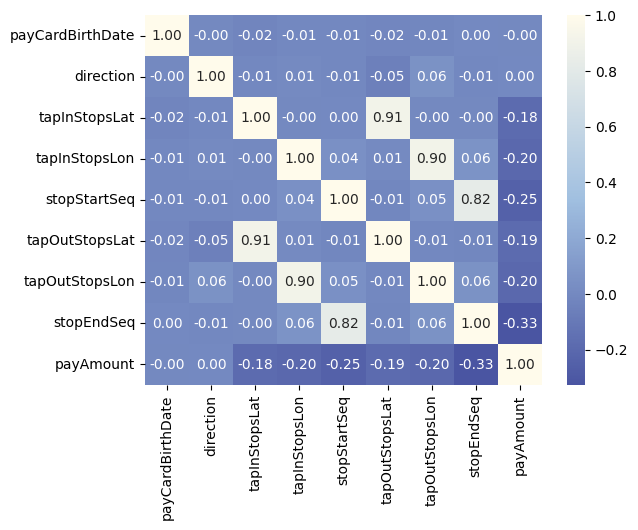

In [6]:
# Korelasi dari variabel-variabel numerik
import matplotlib.colors as colors
color_stops = [(0, '#4A55A2'), (0.5, '#A0BFE0'), (1, '#FFFBEB')]  # Sesuaikan warna dan posisi
custom_cmap = colors.LinearSegmentedColormap.from_list("", color_stops)
sns.heatmap(data_num.corr(), annot=True, fmt='.2f', cmap=custom_cmap)

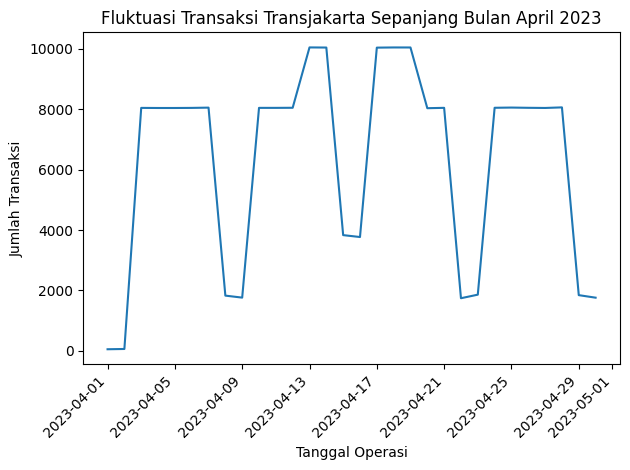

In [14]:
# Assuming 'tapInTime' is in a datetime format
data['tapInTime'] = pd.to_datetime(data['tapInTime'])

# Resample data by day and count transactions
transaction_count = data.resample('D', on='tapInTime')['transID'].count()

# Create line chart with Seaborn
sns.lineplot(x=transaction_count.index, y=transaction_count)
plt.title('Fluktuasi Transaksi Transjakarta Sepanjang Bulan April 2023')
plt.xlabel('Tanggal Operasi')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
transaction_count

tapInTime
2023-04-01       50
2023-04-02       59
2023-04-03     8048
2023-04-04     8045
2023-04-05     8045
2023-04-06     8048
2023-04-07     8057
2023-04-08     1827
2023-04-09     1761
2023-04-10     8049
2023-04-11     8049
2023-04-12     8052
2023-04-13    10052
2023-04-14    10048
2023-04-15     3832
2023-04-16     3769
2023-04-17    10045
2023-04-18    10051
2023-04-19    10050
2023-04-20     8038
2023-04-21     8050
2023-04-22     1741
2023-04-23     1859
2023-04-24     8052
2023-04-25     8059
2023-04-26     8051
2023-04-27     8046
2023-04-28     8065
2023-04-29     1843
2023-04-30     1759
Freq: D, Name: transID, dtype: int64

### Data Unique

In [8]:
unique_payCardBank = data.payCardBank.value_counts().reset_index(name='count')
unique_payCardBank

,payCardBank,count
0,dki,95126
1,emoney,30842
2,brizzi,16486
3,bni,15818
4,online,15664
5,flazz,15564


In [9]:
unique_payCardSex = data.payCardSex.value_counts().reset_index(name='count')
unique_payCardSex

,payCardSex,count
0,F,101790
1,M,87710


In [10]:
unique_direction = data.direction.value_counts().reset_index(name='count')
unique_direction

,direction,count
0,1.0,94802
1,0.0,94698


In [11]:
sorted_paystopstart = data['stopStartSeq'].sort_values()
uniq_paystopstart = sorted_paystopstart.unique()
uniq_paystopstart

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 72, 73, 74, 75], dtype=int64)

# Data Preparation

1. Kolom ‘CorridorName’ dan ‘CorridorID’ sebagai referensi untuk membuat kode wilayah yang kemudian disimpan pada kolom baru, yaitu  kolom ‘wilayah’ yang berisikan 221 kode wilayah dan mengubah kolom payCardSex menjadi numerik
2. Drop kolom yang tidak digunakan
3. Data cleaning

### Assigning Label

In [43]:
# Urutkan DataFrame berdasarkan kolom 'coridorid'
data = data.sort_values(by='corridorID', ascending=True)
data.head()

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
37790,EWBJ585G3S99ML,30206119536552,bni,Ir. Akarsana Januar,F,2010,1,Blok M - Kota,1.0,P00098,...,106.81143,0,2023-04-19 17:09:41,P00138,Museum Fatahillah,-6.13393,106.812090,1.0,2023-04-19 18:06:26,3500.0
13583,JNHK650O1J87QO,4574231689808458,dki,"Cut Clara Prasetyo, S.H.",M,1979,1,Blok M - Kota,0.0,P00017,...,106.80175,0,2023-04-07 16:20:57,NaN,NaN,NaN,NaN,NaN,NaN,3500.0
13579,MWNY480K5N42OK,4837542631469600,dki,Edi Siregar,M,1981,1,Blok M - Kota,0.0,P00261,...,106.82309,9,2023-04-07 17:59:33,P00295,Mangga Besar Arah Utara,-6.15325,106.817536,16.0,2023-04-07 19:21:51,3500.0
31579,PCXG039N8F67GJ,4837542631469600,dki,Edi Siregar,M,1981,1,Blok M - Kota,0.0,P00261,...,106.82309,9,2023-04-17 17:05:20,P00295,Mangga Besar Arah Utara,-6.15325,106.817536,16.0,2023-04-17 17:58:09,3500.0
56021,IUUE843D8L78NO,4687184837144,online,"Puji Zulaika, S.H.",F,2000,1,Blok M - Kota,1.0,P00025,...,106.82300,11,2023-04-27 16:10:52,P00112,Kejaksaan Agung,-6.24050,106.798440,20.0,2023-04-27 17:39:47,3500.0


In [44]:
df = pd.DataFrame(data)

df.loc[(df['corridorID'] == '1') & (df['corridorName'].isna()), 'corridorName'] = 'Blok M - Kota'
df.loc[(df['corridorName'] == 'Blok M - Kota') & (df['corridorID'].isna()), 'corridorID'] = '1'

df.loc[(df['corridorID'] == '2') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gadung - Monas'
df.loc[(df['corridorName'] == 'Pulo Gadung - Monas') & (df['corridorID'].isna()), 'corridorID'] = '2'

df.loc[(df['corridorID'] == '3') & (df['corridorName'].isna()), 'corridorName'] = 'Kalideres - Bundaran HI via Veteran'
df.loc[(df['corridorName'] == 'Kalideres - Bundaran HI via Veteran') & (df['corridorID'].isna()), 'corridorID'] = '3'

df.loc[(df['corridorID'] == '4') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gadung 2 - Tosari'
df.loc[(df['corridorName'] == 'Pulo Gadung 2 - Tosari') & (df['corridorID'].isna()), 'corridorID'] = '4'

df.loc[(df['corridorID'] == '5') & (df['corridorName'].isna()), 'corridorName'] = 'Matraman Baru - Ancol'
df.loc[(df['corridorName'] == 'Matraman Baru - Ancol') & (df['corridorID'].isna()), 'corridorID'] = '5'

df.loc[(df['corridorID'] == '6') & (df['corridorName'].isna()), 'corridorName'] = 'Ragunan - Dukuh Atas 2'
df.loc[(df['corridorName'] == 'Ragunan - Dukuh Atas 2') & (df['corridorID'].isna()), 'corridorID'] = '6'

df.loc[(df['corridorID'] == '7') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Rambutan - Bidara Cina'
df.loc[(df['corridorName'] == 'Kampung Rambutan - Bidara Cina') & (df['corridorID'].isna()), 'corridorID'] = '7'

df.loc[(df['corridorID'] == '8') & (df['corridorName'].isna()), 'corridorName'] = 'Lebak Bulus - Pasar Baru via Tomang'
df.loc[(df['corridorName'] == 'Lebak Bulus - Pasar Baru via Tomang') & (df['corridorID'].isna()), 'corridorID'] = '8'

df.loc[(df['corridorID'] == '9') & (df['corridorName'].isna()), 'corridorName'] = 'Pinang Ranti - Pluit'
df.loc[(df['corridorName'] == 'Pinang Ranti - Pluit') & (df['corridorID'].isna()), 'corridorID'] = '9'

df.loc[(df['corridorID'] == '10') & (df['corridorName'].isna()), 'corridorName'] = 'Tanjung Priok - PGC 2'
df.loc[(df['corridorName'] == 'Tanjung Priok - PGC 2') & (df['corridorID'].isna()), 'corridorID'] = '10'


df.loc[(df['corridorID'] == '11') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gebang - Matraman'
df.loc[(df['corridorName'] == 'Pulo Gebang - Matraman') & (df['corridorID'].isna()), 'corridorID'] = '11'

df.loc[(df['corridorID'] == '12') & (df['corridorName'].isna()), 'corridorName'] = 'Tanjung Priok - Pluit'
df.loc[(df['corridorName'] == 'Tanjung Priok - Pluit') & (df['corridorID'].isna()), 'corridorID'] = '12'

df.loc[(df['corridorID'] == '13') & (df['corridorName'].isna()), 'corridorName'] = 'Ciledug - Tendean'
df.loc[(df['corridorName'] == 'Ciledug - Tendean') & (df['corridorID'].isna()), 'corridorID'] = '13'

df.loc[(df['corridorID'] == '14') & (df['corridorName'].isna()), 'corridorName'] = 'Jakarta International Stadium - Senen'
df.loc[(df['corridorName'] == 'Jakarta International Stadium - Senen') & (df['corridorID'].isna()), 'corridorID'] = '14'

df.loc[(df['corridorID'] == '10A') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Marunda - Tanjung Priok'
df.loc[(df['corridorName'] == 'Rusun Marunda - Tanjung Priok') & (df['corridorID'].isna()), 'corridorID'] = '10A'

df.loc[(df['corridorID'] == '10B') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Cipinang Besar Selatan - Penas Kalimalang'
df.loc[(df['corridorName'] == 'Rusun Cipinang Besar Selatan - Penas Kalimalang') & (df['corridorID'].isna()), 'corridorID'] = '10B'

df.loc[(df['corridorID'] == '10D') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Rambutan - Tanjung Priok'
df.loc[(df['corridorName'] == 'Kampung Rambutan - Tanjung Priok') & (df['corridorID'].isna()), 'corridorID'] = '10D'

df.loc[(df['corridorID'] == '10H') & (df['corridorName'].isna()), 'corridorName'] = 'Tanjung Priok - Blok M'
df.loc[(df['corridorName'] == 'Tanjung Priok - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '10H'

df.loc[(df['corridorID'] == '10K') & (df['corridorName'].isna()), 'corridorName'] = 'Tanjung Priok - Senen via Taman BMW'
df.loc[(df['corridorName'] == 'Tanjung Priok - Senen via Taman BMW') & (df['corridorID'].isna()), 'corridorID'] = '10K'

df.loc[(df['corridorID'] == '11B') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Rawa Bebek - Penggilingan'
df.loc[(df['corridorName'] == 'Rusun Rawa Bebek - Penggilingan') & (df['corridorID'].isna()), 'corridorID'] = '11B'


df.loc[(df['corridorID'] == '11C') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Pinus Elok - Rusun Pulo Gebang'
df.loc[(df['corridorName'] == 'Rusun Pinus Elok - Rusun Pulo Gebang') & (df['corridorID'].isna()), 'corridorID'] = '11C'

df.loc[(df['corridorID'] == '11D') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gebang - Pulo Gadung 2 via PIK'
df.loc[(df['corridorName'] == 'Pulo Gebang - Pulo Gadung 2 via PIK') & (df['corridorID'].isna()), 'corridorID'] = '11D'

df.loc[(df['corridorID'] == '11K') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Komarudin - Penggilingan'
df.loc[(df['corridorName'] == 'Rusun Komarudin - Penggilingan') & (df['corridorID'].isna()), 'corridorID'] = '11K'

df.loc[(df['corridorID'] == '11M') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Rawa Bebek - Bukit Duri'
df.loc[(df['corridorName'] == 'Rusun Rawa Bebek - Bukit Duri') & (df['corridorID'].isna()), 'corridorID'] = '11M'

df.loc[(df['corridorID'] == '11N') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Cipinang Muara - Jatinegara'
df.loc[(df['corridorName'] == 'Rusun Cipinang Muara - Jatinegara') & (df['corridorID'].isna()), 'corridorID'] = '11N'

df.loc[(df['corridorID'] == '11P') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Pondok Bambu - Walikota Jakarta Timur'
df.loc[(df['corridorName'] == 'Rusun Pondok Bambu - Walikota Jakarta Timur') & (df['corridorID'].isna()), 'corridorID'] = '11P'

df.loc[(df['corridorID'] == '11Q') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Melayu - Pulo Gebang via BKT'
df.loc[(df['corridorName'] == 'Kampung Melayu - Pulo Gebang via BKT') & (df['corridorID'].isna()), 'corridorID'] = '11Q'

df.loc[(df['corridorID'] == '12A') & (df['corridorName'].isna()), 'corridorName'] = 'Pelabuhan Kaliadem - Kota'
df.loc[(df['corridorName'] == 'Pelabuhan Kaliadem - Kota') & (df['corridorID'].isna()), 'corridorID'] = '12A'

df.loc[(df['corridorID'] == '12B') & (df['corridorName'].isna()), 'corridorName'] = 'Pluit - Senen'
df.loc[(df['corridorName'] == 'Pluit - Senen') & (df['corridorID'].isna()), 'corridorID'] = '12B'

df.loc[(df['corridorID'] == '12C') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Waduk Pluit - Penjaringan'
df.loc[(df['corridorName'] == 'Rusun Waduk Pluit - Penjaringan') & (df['corridorID'].isna()), 'corridorID'] = '12C'


df.loc[(df['corridorID'] == '12F') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Marunda - Rusun Waduk Pluit'
df.loc[(df['corridorName'] == 'Rusun Marunda - Rusun Waduk Pluit') & (df['corridorID'].isna()), 'corridorID'] = '12F'

df.loc[(df['corridorID'] == '12H') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Penjaringan - Penjaringan'
df.loc[(df['corridorName'] == 'Rusun Penjaringan - Penjaringan') & (df['corridorID'].isna()), 'corridorID'] = '12H'

df.loc[(df['corridorID'] == '12P') & (df['corridorName'].isna()), 'corridorName'] = 'St. LRT Pegangsaan Dua - JIS'
df.loc[(df['corridorName'] == 'St. LRT Pegangsaan Dua - JIS') & (df['corridorID'].isna()), 'corridorID'] = '12P'

df.loc[(df['corridorID'] == '13B') & (df['corridorName'].isna()), 'corridorName'] = 'Puri Beta - Pancoran Barat'
df.loc[(df['corridorName'] == 'Puri Beta - Pancoran Barat') & (df['corridorID'].isna()), 'corridorID'] = '13B'

df.loc[(df['corridorID'] == '13C') & (df['corridorName'].isna()), 'corridorName'] = 'Puri Beta - Dukuh Atas'
df.loc[(df['corridorName'] == 'Puri Beta - Dukuh Atas') & (df['corridorID'].isna()), 'corridorID'] = '13C'

df.loc[(df['corridorID'] == '13D') & (df['corridorName'].isna()), 'corridorName'] = 'Puri Beta - Ragunan'
df.loc[(df['corridorName'] == 'Puri Beta - Ragunan') & (df['corridorID'].isna()), 'corridorID'] = '13D'

df.loc[(df['corridorID'] == '1A') & (df['corridorName'].isna()), 'corridorName'] = 'Pantai Maju - Balai Kota'
df.loc[(df['corridorName'] == 'Pantai Maju - Balai Kota') & (df['corridorID'].isna()), 'corridorID'] = '1A'

df.loc[(df['corridorID'] == '1B') & (df['corridorName'].isna()), 'corridorName'] = 'Stasiun Palmerah - Tosari'
df.loc[(df['corridorName'] == 'Stasiun Palmerah - Tosari') & (df['corridorID'].isna()), 'corridorID'] = '1B'

df.loc[(df['corridorID'] == '1C') & (df['corridorName'].isna()), 'corridorName'] = 'Pesanggrahan - Blok M'
df.loc[(df['corridorName'] == 'Pesanggrahan - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '1C'

df.loc[(df['corridorID'] == '1E') & (df['corridorName'].isna()), 'corridorName'] = 'Pondok Labu - Blok M'
df.loc[(df['corridorName'] == 'Pondok Labu - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '1E'


df.loc[(df['corridorID'] == '1F') & (df['corridorName'].isna()), 'corridorName'] = 'Stasiun Palmerah - Bundaran Senayan'
df.loc[(df['corridorName'] == 'Stasiun Palmerah - Bundaran Senayan') & (df['corridorID'].isna()), 'corridorID'] = '1F'

df.loc[(df['corridorID'] == '1H') & (df['corridorName'].isna()), 'corridorName'] = 'Tanah Abang - Stasiun Gondangdia'
df.loc[(df['corridorName'] == 'Tanah Abang - Stasiun Gondangdia') & (df['corridorID'].isna()), 'corridorID'] = '1H'

df.loc[(df['corridorID'] == '1K') & (df['corridorName'].isna()), 'corridorName'] = 'Cibubur Junction - Blok M'
df.loc[(df['corridorName'] == 'Cibubur Junction - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '1K'

df.loc[(df['corridorID'] == '1M') & (df['corridorName'].isna()), 'corridorName'] = 'Meruya - Blok M'
df.loc[(df['corridorName'] == 'Meruya - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '1M'

df.loc[(df['corridorID'] == '1N') & (df['corridorName'].isna()), 'corridorName'] = 'Tanah Abang - Blok M'
df.loc[(df['corridorName'] == 'Tanah Abang - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '1N'

df.loc[(df['corridorID'] == '1P') & (df['corridorName'].isna()), 'corridorName'] = 'Senen - Blok M'
df.loc[(df['corridorName'] == 'Senen - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '1P'

df.loc[(df['corridorID'] == '1Q') & (df['corridorName'].isna()), 'corridorName'] = 'Rempoa - Blok M'
df.loc[(df['corridorName'] == 'Rempoa - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '1Q'

df.loc[(df['corridorID'] == '1R') & (df['corridorName'].isna()), 'corridorName'] = 'Senen - Tanah Abang'
df.loc[(df['corridorName'] == 'Senen - Tanah Abang') & (df['corridorID'].isna()), 'corridorID'] = '1R'

df.loc[(df['corridorID'] == '1T') & (df['corridorName'].isna()), 'corridorName'] = 'Cibubur - Balai Kota'
df.loc[(df['corridorName'] == 'Cibubur - Balai Kota') & (df['corridorID'].isna()), 'corridorID'] = '1T'

df.loc[(df['corridorID'] == '2A') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gadung - Rawa Buaya via Balai Kota'
df.loc[(df['corridorName'] == 'Pulo Gadung - Rawa Buaya via Balai Kota') & (df['corridorID'].isna()), 'corridorID'] = '2A'


df.loc[(df['corridorID'] == '2B') & (df['corridorName'].isna()), 'corridorName'] = 'Harapan Indah - ASMI'
df.loc[(df['corridorName'] == 'Harapan Indah - ASMI') & (df['corridorID'].isna()), 'corridorID'] = '2B'

df.loc[(df['corridorID'] == '2E') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Rawa Bebek - Kodamar'
df.loc[(df['corridorName'] == 'Rusun Rawa Bebek - Kodamar') & (df['corridorID'].isna()), 'corridorID'] = '2E'

df.loc[(df['corridorID'] == '2F') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Cakung Barat - Pulo Gadung'
df.loc[(df['corridorName'] == 'Rusun Cakung Barat - Pulo Gadung') & (df['corridorID'].isna()), 'corridorID'] = '2F'

df.loc[(df['corridorID'] == '2H') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Jati Rawasari - Senen'
df.loc[(df['corridorName'] == 'Rusun Jati Rawasari - Senen') & (df['corridorID'].isna()), 'corridorID'] = '2H'

df.loc[(df['corridorID'] == '2P') & (df['corridorName'].isna()), 'corridorName'] = 'Gondangdia - Senen'
df.loc[(df['corridorName'] == 'Gondangdia - Senen') & (df['corridorID'].isna()), 'corridorID'] = '2P'

df.loc[(df['corridorID'] == '2Q') & (df['corridorName'].isna()), 'corridorName'] = 'Gondangdia - Balai Kota'
df.loc[(df['corridorName'] == 'Gondangdia - Balai Kota') & (df['corridorID'].isna()), 'corridorID'] = '2Q'

df.loc[(df['corridorID'] == '3A') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Pesakih - Kalideres'
df.loc[(df['corridorName'] == 'Rusun Pesakih - Kalideres') & (df['corridorID'].isna()), 'corridorID'] = '3A'

df.loc[(df['corridorID'] == '3B') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Flamboyan - Cengkareng'
df.loc[(df['corridorName'] == 'Rusun Flamboyan - Cengkareng') & (df['corridorID'].isna()), 'corridorID'] = '3B'

df.loc[(df['corridorID'] == '3C') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Kapuk Muara - Penjaringan'
df.loc[(df['corridorName'] == 'Rusun Kapuk Muara - Penjaringan') & (df['corridorID'].isna()), 'corridorID'] = '3C'

df.loc[(df['corridorID'] == '3E') & (df['corridorName'].isna()), 'corridorName'] = 'Puri Kembangan - Sentraland Cengkareng'
df.loc[(df['corridorName'] == 'Puri Kembangan - Sentraland Cengkareng') & (df['corridorID'].isna()), 'corridorID'] = '3E'


df.loc[(df['corridorID'] == '3F') & (df['corridorName'].isna()), 'corridorName'] = 'Kalideres - Gelora Bung Karno'
df.loc[(df['corridorName'] == 'Kalideres - Gelora Bung Karno') & (df['corridorID'].isna()), 'corridorID'] = '3F'

df.loc[(df['corridorID'] == '3H') & (df['corridorName'].isna()), 'corridorName'] = 'Jelambar - Kota'
df.loc[(df['corridorName'] == 'Jelambar - Kota') & (df['corridorID'].isna()), 'corridorID'] = '3H'

df.loc[(df['corridorID'] == '4B') & (df['corridorName'].isna()), 'corridorName'] = 'Stasiun Manggarai - UI'
df.loc[(df['corridorName'] == 'Stasiun Manggarai - UI') & (df['corridorID'].isna()), 'corridorID'] = '4B'

df.loc[(df['corridorID'] == '4C') & (df['corridorName'].isna()), 'corridorName'] = 'TU Gas - Bundaran Senayan'
df.loc[(df['corridorName'] == 'TU Gas - Bundaran Senayan') & (df['corridorID'].isna()), 'corridorID'] = '4C'

df.loc[(df['corridorID'] == '4D') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gadung 2 - Kuningan'
df.loc[(df['corridorName'] == 'Pulo Gadung 2 - Kuningan') & (df['corridorID'].isna()), 'corridorID'] = '4D'

df.loc[(df['corridorID'] == '4E') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Jatinegara Kaum - Pulo Gadung'
df.loc[(df['corridorName'] == 'Rusun Jatinegara Kaum - Pulo Gadung') & (df['corridorID'].isna()), 'corridorID'] = '4E'

df.loc[(df['corridorID'] == '4F') & (df['corridorName'].isna()), 'corridorName'] = 'Pinang Ranti - Pulo Gadung'
df.loc[(df['corridorName'] == 'Pinang Ranti - Pulo Gadung') & (df['corridorID'].isna()), 'corridorID'] = '4F'

df.loc[(df['corridorID'] == '5B') & (df['corridorName'].isna()), 'corridorName'] = 'Stasiun Tebet - BNN'
df.loc[(df['corridorName'] == 'Stasiun Tebet - BNN') & (df['corridorID'].isna()), 'corridorID'] = '5B'

df.loc[(df['corridorID'] == '5C') & (df['corridorName'].isna()), 'corridorName'] = 'PGC - Juanda'
df.loc[(df['corridorName'] == 'PGC - Juanda') & (df['corridorID'].isna()), 'corridorID'] = '5C'

df.loc[(df['corridorID'] == '5D') & (df['corridorName'].isna()), 'corridorName'] = 'PGC 1 - Ancol'
df.loc[(df['corridorName'] == 'PGC 1 - Ancol') & (df['corridorID'].isna()), 'corridorID'] = '5D'


df.loc[(df['corridorID'] == '5F') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Melayu - Tanah Abang'
df.loc[(df['corridorName'] == 'Kampung Melayu - Tanah Abang') & (df['corridorID'].isna()), 'corridorID'] = '5F'

df.loc[(df['corridorID'] == '5M') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Melayu - Tanah Abang via Cikini'
df.loc[(df['corridorName'] == 'Kampung Melayu - Tanah Abang via Cikini') & (df['corridorID'].isna()), 'corridorID'] = '5M'

df.loc[(df['corridorID'] == '5N') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Melayu - Ragunan'
df.loc[(df['corridorName'] == 'Kampung Melayu - Ragunan') & (df['corridorID'].isna()), 'corridorID'] = '5N'

df.loc[(df['corridorID'] == '6A') & (df['corridorName'].isna()), 'corridorName'] = 'Ragunan - MH Thamrin via Kuningan'
df.loc[(df['corridorName'] == 'Ragunan - MH Thamrin via Kuningan') & (df['corridorID'].isna()), 'corridorID'] = '6A'

df.loc[(df['corridorID'] == '6B') & (df['corridorName'].isna()), 'corridorName'] = 'Ragunan - MH Thamrin via Semanggi'
df.loc[(df['corridorName'] == 'Ragunan - MH Thamrin via Semanggi') & (df['corridorID'].isna()), 'corridorID'] = '6B'

df.loc[(df['corridorID'] == '6C') & (df['corridorName'].isna()), 'corridorName'] = 'Stasiun Tebet - Karet via Patra Kuningan'
df.loc[(df['corridorName'] == 'Stasiun Tebet - Karet via Patra Kuningan') & (df['corridorID'].isna()), 'corridorID'] = '6C'

df.loc[(df['corridorID'] == '6D') & (df['corridorName'].isna()), 'corridorName'] = 'Stasiun Tebet - Karet via Underpass'
df.loc[(df['corridorName'] == 'Stasiun Tebet - Karet via Underpass') & (df['corridorID'].isna()), 'corridorID'] = '6D'

df.loc[(df['corridorID'] == '6H') & (df['corridorName'].isna()), 'corridorName'] = 'Senen - Lebak Bulus'
df.loc[(df['corridorName'] == 'Senen - Lebak Bulus') & (df['corridorID'].isna()), 'corridorID'] = '6H'

df.loc[(df['corridorID'] == '6M') & (df['corridorName'].isna()), 'corridorName'] = 'Stasiun Manggarai - Blok M'
df.loc[(df['corridorName'] == 'Stasiun Manggarai - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '6M'

df.loc[(df['corridorID'] == '6N') & (df['corridorName'].isna()), 'corridorName'] = 'Ragunan - Blok M via Kemang'
df.loc[(df['corridorName'] == 'Ragunan - Blok M via Kemang') & (df['corridorID'].isna()), 'corridorID'] = '6N'


df.loc[(df['corridorID'] == '6P') & (df['corridorName'].isna()), 'corridorName'] = 'Cibubur - Kuningan'
df.loc[(df['corridorName'] == 'Cibubur - Kuningan') & (df['corridorID'].isna()), 'corridorID'] = '6P'

df.loc[(df['corridorID'] == '6Q') & (df['corridorName'].isna()), 'corridorName'] = 'Dukuh Atas - Casablanca via Epicentrum Raya'
df.loc[(df['corridorName'] == 'Dukuh Atas - Casablanca via Epicentrum Raya') & (df['corridorID'].isna()), 'corridorID'] = '6Q'

df.loc[(df['corridorID'] == '6T') & (df['corridorName'].isna()), 'corridorName'] = 'Pasar Minggu - Velbak'
df.loc[(df['corridorName'] == 'Pasar Minggu - Velbak') & (df['corridorID'].isna()), 'corridorID'] = '6T'

df.loc[(df['corridorID'] == '6U') & (df['corridorName'].isna()), 'corridorName'] = 'Blok M - Pasar Minggu'
df.loc[(df['corridorName'] == 'Blok M - Pasar Minggu') & (df['corridorID'].isna()), 'corridorID'] = '6U'

df.loc[(df['corridorID'] == '6V') & (df['corridorName'].isna()), 'corridorName'] = 'Ragunan - Gelora Bung Karno'
df.loc[(df['corridorName'] == 'Ragunan - Gelora Bung Karno') & (df['corridorID'].isna()), 'corridorID'] = '6V'

df.loc[(df['corridorID'] == '7A') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Rambutan - Lebak Bulus'
df.loc[(df['corridorName'] == 'Kampung Rambutan - Lebak Bulus') & (df['corridorID'].isna()), 'corridorID'] = '7A'

df.loc[(df['corridorID'] == '7B') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Rambutan - Blok M'
df.loc[(df['corridorName'] == 'Kampung Rambutan - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '7B'

df.loc[(df['corridorID'] == '7C') & (df['corridorName'].isna()), 'corridorName'] = 'Cibubur - BKN'
df.loc[(df['corridorName'] == 'Cibubur - BKN') & (df['corridorID'].isna()), 'corridorID'] = '7C'

df.loc[(df['corridorID'] == '7D') & (df['corridorName'].isna()), 'corridorName'] = 'Pancoran - Kampung Rambutan'
df.loc[(df['corridorName'] == 'Pancoran - Kampung Rambutan') & (df['corridorID'].isna()), 'corridorID'] = '7D'

df.loc[(df['corridorID'] == '7E') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Rambutan - Ragunan'
df.loc[(df['corridorName'] == 'Kampung Rambutan - Ragunan') & (df['corridorID'].isna()), 'corridorID'] = '7E'


df.loc[(df['corridorID'] == '7F') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Rambutan - Juanda via Pasar Baru'
df.loc[(df['corridorName'] == 'Kampung Rambutan - Juanda via Pasar Baru') & (df['corridorID'].isna()), 'corridorID'] = '7F'

df.loc[(df['corridorID'] == '7P') & (df['corridorName'].isna()), 'corridorName'] = 'Pondok Kelapa - BKN'
df.loc[(df['corridorName'] == 'Pondok Kelapa - BKN') & (df['corridorID'].isna()), 'corridorID'] = '7P'

df.loc[(df['corridorID'] == '7Q') & (df['corridorName'].isna()), 'corridorName'] = 'Blok M - PGC'
df.loc[(df['corridorName'] == 'Blok M - PGC') & (df['corridorID'].isna()), 'corridorID'] = '7Q'

df.loc[(df['corridorID'] == '8A') & (df['corridorName'].isna()), 'corridorName'] = 'Jelambar - Juanda'
df.loc[(df['corridorName'] == 'Jelambar - Juanda') & (df['corridorID'].isna()), 'corridorID'] = '8A'

df.loc[(df['corridorID'] == '8C') & (df['corridorName'].isna()), 'corridorName'] = 'Kebayoran Lama - Tanah Abang'
df.loc[(df['corridorName'] == 'Kebayoran Lama - Tanah Abang') & (df['corridorID'].isna()), 'corridorID'] = '8C'

df.loc[(df['corridorID'] == '8D') & (df['corridorName'].isna()), 'corridorName'] = 'Joglo - Blok M'
df.loc[(df['corridorName'] == 'Joglo - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '8D'

df.loc[(df['corridorID'] == '8E') & (df['corridorName'].isna()), 'corridorName'] = 'Bintaro - Blok M'
df.loc[(df['corridorName'] == 'Bintaro - Blok M') & (df['corridorID'].isna()), 'corridorID'] = '8E'

df.loc[(df['corridorID'] == '8K') & (df['corridorName'].isna()), 'corridorName'] = 'Batusari - Grogol'
df.loc[(df['corridorName'] == 'Batusari - Grogol') & (df['corridorID'].isna()), 'corridorID'] = '8K'

df.loc[(df['corridorID'] == '8M') & (df['corridorName'].isna()), 'corridorName'] = 'S. Parman - Tanah Abang'
df.loc[(df['corridorName'] == 'S. Parman - Tanah Abang') & (df['corridorID'].isna()), 'corridorID'] = '8M'

df.loc[(df['corridorID'] == '9A') & (df['corridorName'].isna()), 'corridorName'] = 'PGC 2 - Grogol 2'
df.loc[(df['corridorName'] == 'PGC 2 - Grogol 2') & (df['corridorID'].isna()), 'corridorID'] = '9A'


df.loc[(df['corridorID'] == '9C') & (df['corridorName'].isna()), 'corridorName'] = 'Pinang Ranti - Bundaran Senayan'
df.loc[(df['corridorName'] == 'Pinang Ranti - Bundaran Senayan') & (df['corridorID'].isna()), 'corridorID'] = '9C'

df.loc[(df['corridorID'] == '9D') & (df['corridorName'].isna()), 'corridorName'] = 'Pasar Minggu - Tanah Abang'
df.loc[(df['corridorName'] == 'Pasar Minggu - Tanah Abang') & (df['corridorID'].isna()), 'corridorID'] = '9D'

df.loc[(df['corridorID'] == '9E') & (df['corridorName'].isna()), 'corridorName'] = 'Kebayoran Lama - Jelambar'
df.loc[(df['corridorName'] == 'Kebayoran Lama - Jelambar') & (df['corridorID'].isna()), 'corridorID'] = '9E'

df.loc[(df['corridorID'] == '9F') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Tambora - Pluit'
df.loc[(df['corridorName'] == 'Rusun Tambora - Pluit') & (df['corridorID'].isna()), 'corridorID'] = '9F'

df.loc[(df['corridorID'] == '9H') & (df['corridorName'].isna()), 'corridorName'] = 'Blok M - Universitas Indonesia'
df.loc[(df['corridorName'] == 'Blok M - Universitas Indonesia') & (df['corridorID'].isna()), 'corridorID'] = '9H'

df.loc[(df['corridorID'] == '9N') & (df['corridorName'].isna()), 'corridorName'] = 'Pinang Ranti - Pramuka'
df.loc[(df['corridorName'] == 'Pinang Ranti - Pramuka') & (df['corridorID'].isna()), 'corridorID'] = '9N'

df.loc[(df['corridorID'] == 'B11') & (df['corridorName'].isna()), 'corridorName'] = 'Summarecon Bekasi - BNN'
df.loc[(df['corridorName'] == 'Summarecon Bekasi - BNN') & (df['corridorID'].isna()), 'corridorID'] = 'B11'

df.loc[(df['corridorID'] == 'B13') & (df['corridorName'].isna()), 'corridorName'] = 'Bekasi Barat - Blok M'
df.loc[(df['corridorName'] == 'Bekasi Barat - Blok M') & (df['corridorID'].isna()), 'corridorID'] = 'B13'

df.loc[(df['corridorID'] == 'B14') & (df['corridorName'].isna()), 'corridorName'] = 'Bekasi Barat - Kuningan'
df.loc[(df['corridorName'] == 'Bekasi Barat - Kuningan') & (df['corridorID'].isna()), 'corridorID'] = 'B14'

df.loc[(df['corridorID'] == 'B21') & (df['corridorName'].isna()), 'corridorName'] = 'Bekasi Timur - Cawang'
df.loc[(df['corridorName'] == 'Bekasi Timur - Cawang') & (df['corridorID'].isna()), 'corridorID'] = 'B21'


In [45]:
df.loc[(df['corridorID'] == 'BW9') & (df['corridorName'].isna()), 'corridorName'] = 'Monas - Pantai Indah Kapuk'
df.loc[(df['corridorName'] == 'Monas - Pantai Indah Kapuk') & (df['corridorID'].isna()), 'corridorID'] = 'BW9'

df.loc[(df['corridorID'] == 'D11') & (df['corridorName'].isna()), 'corridorName'] = 'Depok - BKN'
df.loc[(df['corridorName'] == 'Depok - BKN') & (df['corridorID'].isna()), 'corridorID'] = 'D11'

df.loc[(df['corridorID'] == 'D21') & (df['corridorName'].isna()), 'corridorName'] = 'Universitas Indonesia - Lebak Bulus'
df.loc[(df['corridorName'] == 'Universitas Indonesia - Lebak Bulus') & (df['corridorID'].isna()), 'corridorID'] = 'D21'

df.loc[(df['corridorID'] == 'D31') & (df['corridorName'].isna()), 'corridorName'] = 'Cinere - Kuningan'
df.loc[(df['corridorName'] == 'Cinere - Kuningan') & (df['corridorID'].isna()), 'corridorID'] = 'D31'

df.loc[(df['corridorID'] == 'D32') & (df['corridorName'].isna()), 'corridorName'] = 'Cinere - Bundaran Senayan'
df.loc[(df['corridorName'] == 'Cinere - Bundaran Senayan') & (df['corridorID'].isna()), 'corridorID'] = 'D32'

df.loc[(df['corridorID'] == 'JAK.01') & (df['corridorName'].isna()), 'corridorName'] = 'Tanjung Priok - Plumpang'
df.loc[(df['corridorName'] == 'Tanjung Priok - Plumpang') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.01'

df.loc[(df['corridorID'] == 'JAK.02') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Melayu - Duren Sawit'
df.loc[(df['corridorName'] == 'Kampung Melayu - Duren Sawit') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.02'

df.loc[(df['corridorID'] == 'JAK.03') & (df['corridorName'].isna()), 'corridorName'] = 'Lebak Bulus - Andara'
df.loc[(df['corridorName'] == 'Lebak Bulus - Andara') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.03'


df.loc[(df['corridorID'] == 'JAK.04') & (df['corridorName'].isna()), 'corridorName'] = 'Grogol - Tubagus Angke'
df.loc[(df['corridorName'] == 'Grogol - Tubagus Angke') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.04'

df.loc[(df['corridorID'] == 'JAK.05') & (df['corridorName'].isna()), 'corridorName'] = 'Semper - Rorotan'
df.loc[(df['corridorName'] == 'Semper - Rorotan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.05'

df.loc[(df['corridorID'] == 'JAK.06') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Rambutan - Pondok Gede'
df.loc[(df['corridorName'] == 'Kampung Rambutan - Pondok Gede') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.06'

df.loc[(df['corridorID'] == 'JAK.07') & (df['corridorName'].isna()), 'corridorName'] = 'Tanah Abang - Grogol via Tawakal'
df.loc[(df['corridorName'] == 'Tanah Abang - Grogol via Tawakal') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.07'

df.loc[(df['corridorID'] == 'JAK.08') & (df['corridorName'].isna()), 'corridorName'] = 'Roxy - Benhil'
df.loc[(df['corridorName'] == 'Roxy - Benhil') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.08'

df.loc[(df['corridorID'] == 'JAK.10') & (df['corridorName'].isna()), 'corridorName'] = 'Tanah Abang - Kota'
df.loc[(df['corridorName'] == 'Tanah Abang - Kota') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.10'

df.loc[(df['corridorID'] == 'JAK.106') & (df['corridorName'].isna()), 'corridorName'] = 'Terminal Kampung Melayu - Terminal Klender'
df.loc[(df['corridorName'] == 'Terminal Kampung Melayu - Terminal Klender') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.106'

df.loc[(df['corridorID'] == 'JAK.11') & (df['corridorName'].isna()), 'corridorName'] = 'Tanah Abang - Kebayoran Lama'
df.loc[(df['corridorName'] == 'Tanah Abang - Kebayoran Lama') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.11'

df.loc[(df['corridorID'] == 'JAK.110A') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Marunda - Terminal Terpadu Pulo Gebang'
df.loc[(df['corridorName'] == 'Rusun Marunda - Terminal Terpadu Pulo Gebang') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.110A'


df.loc[(df['corridorID'] == 'JAK.112') & (df['corridorName'].isna()), 'corridorName'] = 'Terminal Tanah Merah - Pulo Gadung'
df.loc[(df['corridorName'] == 'Terminal Tanah Merah - Pulo Gadung') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.112'

df.loc[(df['corridorID'] == 'JAK.113') & (df['corridorName'].isna()), 'corridorName'] = 'Rusun Sindang Koja - Kp. Sawah'
df.loc[(df['corridorName'] == 'Rusun Sindang Koja - Kp. Sawah') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.113'

df.loc[(df['corridorID'] == 'JAK.115') & (df['corridorName'].isna()), 'corridorName'] = 'Term. Tj. Priok - Pegangsaan II IGI'
df.loc[(df['corridorName'] == 'Term. Tj. Priok - Pegangsaan II IGI') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.115'

df.loc[(df['corridorID'] == 'JAK.117') & (df['corridorName'].isna()), 'corridorName'] = 'Tanjung Priok - Tanah Merdeka'
df.loc[(df['corridorName'] == 'Tanjung Priok - Tanah Merdeka') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.117'

df.loc[(df['corridorID'] == 'JAK.118') & (df['corridorName'].isna()), 'corridorName'] = 'Taman Waduk Papanggo - Kota Tua'
df.loc[(df['corridorName'] == 'Taman Waduk Papanggo - Kota Tua') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.118'

df.loc[(df['corridorID'] == 'JAK.12') & (df['corridorName'].isna()), 'corridorName'] = 'Tanah Abang - Kebayoran Lama via Pos Pengumben'
df.loc[(df['corridorName'] == 'Tanah Abang - Kebayoran Lama via Pos Pengumben') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.12'

df.loc[(df['corridorID'] == 'JAK.120') & (df['corridorName'].isna()), 'corridorName'] = 'JIS - Terminal Muara Angke'
df.loc[(df['corridorName'] == 'JIS - Terminal Muara Angke') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.120'

df.loc[(df['corridorID'] == 'JAK.13') & (df['corridorName'].isna()), 'corridorName'] = 'Tanah Abang - Jembatan Lima'
df.loc[(df['corridorName'] == 'Tanah Abang - Jembatan Lima') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.13'

df.loc[(df['corridorID'] == 'JAK.14') & (df['corridorName'].isna()), 'corridorName'] = 'Tanah Abang - Meruya'
df.loc[(df['corridorName'] == 'Tanah Abang - Meruya') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.14'

df.loc[(df['corridorID'] == 'JAK.15') & (df['corridorName'].isna()), 'corridorName'] = 'Bulak Turi - Tanjung Priok'
df.loc[(df['corridorName'] == 'Bulak Turi - Tanjung Priok') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.15'

df.loc[(df['corridorID'] == 'JAK.16') & (df['corridorName'].isna()), 'corridorName'] = 'Cililitan - Condet'
df.loc[(df['corridorName'] == 'Cililitan - Condet') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.16'

df.loc[(df['corridorID'] == 'JAK.17') & (df['corridorName'].isna()), 'corridorName'] = 'Senen - Pulo Gadung'
df.loc[(df['corridorName'] == 'Senen - Pulo Gadung') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.17'

df.loc[(df['corridorID'] == 'JAK.18') & (df['corridorName'].isna()), 'corridorName'] = 'Kalibata - Kuningan'
df.loc[(df['corridorName'] == 'Kalibata - Kuningan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.18'

df.loc[(df['corridorID'] == 'JAK.19') & (df['corridorName'].isna()), 'corridorName'] = 'Pinang Ranti - Kampung Rambutan'
df.loc[(df['corridorName'] == 'Pinang Ranti - Kampung Rambutan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.19'

df.loc[(df['corridorID'] == 'JAK.20') & (df['corridorName'].isna()), 'corridorName'] = 'Cawang UKI - Lubang Buaya'
df.loc[(df['corridorName'] == 'Cawang UKI - Lubang Buaya') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.20'

df.loc[(df['corridorID'] == 'JAK.21') & (df['corridorName'].isna()), 'corridorName'] = 'Cililitan - Dwikora'
df.loc[(df['corridorName'] == 'Cililitan - Dwikora') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.21'

df.loc[(df['corridorID'] == 'JAK.22') & (df['corridorName'].isna()), 'corridorName'] = 'Dwikora - Penas Kalimalang'
df.loc[(df['corridorName'] == 'Dwikora - Penas Kalimalang') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.22'

df.loc[(df['corridorID'] == 'JAK.23') & (df['corridorName'].isna()), 'corridorName'] = 'Senen - Pisangan Baru'
df.loc[(df['corridorName'] == 'Senen - Pisangan Baru') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.23'

df.loc[(df['corridorID'] == 'JAK.24') & (df['corridorName'].isna()), 'corridorName'] = 'Senen - Pulo Gadung via Kelapa Gading'
df.loc[(df['corridorName'] == 'Senen - Pulo Gadung via Kelapa Gading') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.24'

df.loc[(df['corridorID'] == 'JAK.25') & (df['corridorName'].isna()), 'corridorName'] = 'Kp. Rambutan - Kalisari'
df.loc[(df['corridorName'] == 'Kp. Rambutan - Kalisari') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.25'

df.loc[(df['corridorID'] == 'JAK.26') & (df['corridorName'].isna()), 'corridorName'] = 'Rawamangun - Duren Sawit'
df.loc[(df['corridorName'] == 'Rawamangun - Duren Sawit') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.26'

df.loc[(df['corridorID'] == 'JAK.27') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gebang - Rorotan'
df.loc[(df['corridorName'] == 'Pulo Gebang - Rorotan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.27'

df.loc[(df['corridorID'] == 'JAK.28') & (df['corridorName'].isna()), 'corridorName'] = 'Kp. Rambutan - Taman Wiladatika'
df.loc[(df['corridorName'] == 'Kp. Rambutan - Taman Wiladatika') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.28'

df.loc[(df['corridorID'] == 'JAK.29') & (df['corridorName'].isna()), 'corridorName'] = 'Tanjung Priok - Sukapura'
df.loc[(df['corridorName'] == 'Tanjung Priok - Sukapura') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.29'

df.loc[(df['corridorID'] == 'JAK.30') & (df['corridorName'].isna()), 'corridorName'] = 'Grogol - Meruya via Roxy'
df.loc[(df['corridorName'] == 'Grogol - Meruya via Roxy') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.30'

df.loc[(df['corridorID'] == 'JAK.31') & (df['corridorName'].isna()), 'corridorName'] = 'Blok M - Andara'
df.loc[(df['corridorName'] == 'Blok M - Andara') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.31'

df.loc[(df['corridorID'] == 'JAK.32') & (df['corridorName'].isna()), 'corridorName'] = 'Lebak Bulus - Petukangan'
df.loc[(df['corridorName'] == 'Lebak Bulus - Petukangan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.32'

df.loc[(df['corridorID'] == 'JAK.33') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gadung - Kota'
df.loc[(df['corridorName'] == 'Pulo Gadung - Kota') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.33'

df.loc[(df['corridorID'] == 'JAK.34') & (df['corridorName'].isna()), 'corridorName'] = 'Rawamangun - Klender'
df.loc[(df['corridorName'] == 'Rawamangun - Klender') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.34'

df.loc[(df['corridorID'] == 'JAK.35') & (df['corridorName'].isna()), 'corridorName'] = 'Pangkalan Jati - Rawamangun'
df.loc[(df['corridorName'] == 'Pangkalan Jati - Rawamangun') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.35'

df.loc[(df['corridorID'] == 'JAK.36') & (df['corridorName'].isna()), 'corridorName'] = 'Cilangkap - Cililitan'
df.loc[(df['corridorName'] == 'Cilangkap - Cililitan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.36'

df.loc[(df['corridorID'] == 'JAK.37') & (df['corridorName'].isna()), 'corridorName'] = 'Cililitan - Condet via Kayu Manis'
df.loc[(df['corridorName'] == 'Cililitan - Condet via Kayu Manis') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.37'

df.loc[(df['corridorID'] == 'JAK.38') & (df['corridorName'].isna()), 'corridorName'] = 'Bulak Ringin - Kampung Rambutan'
df.loc[(df['corridorName'] == 'Bulak Ringin - Kampung Rambutan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.38'

df.loc[(df['corridorID'] == 'JAK.39') & (df['corridorName'].isna()), 'corridorName'] = 'Kalimalang - Duren Sawit'
df.loc[(df['corridorName'] == 'Kalimalang - Duren Sawit') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.39'

df.loc[(df['corridorID'] == 'JAK.40') & (df['corridorName'].isna()), 'corridorName'] = 'Harapan Baru - Pulo Gebang via Rawa Kuning'
df.loc[(df['corridorName'] == 'Harapan Baru - Pulo Gebang via Rawa Kuning') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.40'

df.loc[(df['corridorID'] == 'JAK.41') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Melayu - Pulo Gadung'
df.loc[(df['corridorName'] == 'Kampung Melayu - Pulo Gadung') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.41'

df.loc[(df['corridorID'] == 'JAK.42') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Melayu - Pondok Kelapa'
df.loc[(df['corridorName'] == 'Kampung Melayu - Pondok Kelapa') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.42'

df.loc[(df['corridorID'] == 'JAK.43B') & (df['corridorName'].isna()), 'corridorName'] = 'Tongtek - Tebet Eco Park (TEP) - Cililitan'
df.loc[(df['corridorName'] == 'Tongtek - Tebet Eco Park (TEP) - Cililitan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.43B'

df.loc[(df['corridorID'] == 'JAK.43C') & (df['corridorName'].isna()), 'corridorName'] = 'Sarana Jaya - Tebet Eco Park (TEP) - Stasiun Cawang'
df.loc[(df['corridorName'] == 'TSarana Jaya - Tebet Eco Park (TEP) - Stasiun Cawang') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.43C'

df.loc[(df['corridorID'] == 'JAK.44') & (df['corridorName'].isna()), 'corridorName'] = 'Andara - Stasiun Universitas Pancasila'
df.loc[(df['corridorName'] == 'Andara - Stasiun Universitas Pancasila') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.44'

df.loc[(df['corridorID'] == 'JAK.45') & (df['corridorName'].isna()), 'corridorName'] = 'Lebak Bulus - Ragunan'
df.loc[(df['corridorName'] == 'Lebak Bulus - Ragunan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.45'

df.loc[(df['corridorID'] == 'JAK.46') & (df['corridorName'].isna()), 'corridorName'] = 'Pasar Minggu - Jagakarsa'
df.loc[(df['corridorName'] == 'Pasar Minggu - Jagakarsa') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.46'

df.loc[(df['corridorID'] == 'JAK.47') & (df['corridorName'].isna()), 'corridorName'] = 'Pasar Minggu - Ciganjur via KB Ragunan'
df.loc[(df['corridorName'] == 'Pasar Minggu - Ciganjur via KB Ragunan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.47'

df.loc[(df['corridorID'] == 'JAK.48A') & (df['corridorName'].isna()), 'corridorName'] = 'Stasiun Tebet - Rusun Karet Tengsin'
df.loc[(df['corridorName'] == 'Stasiun Tebet - Rusun Karet Tengsin') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.48A'

df.loc[(df['corridorID'] == 'JAK.48B') & (df['corridorName'].isna()), 'corridorName'] = 'Stasiun Tebet - Kampung Melayu'
df.loc[(df['corridorName'] == 'Stasiun Tebet - Kampung Melayu') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.48B'

df.loc[(df['corridorID'] == 'JAK.49') & (df['corridorName'].isna()), 'corridorName'] = 'Lebak Bulus - Cipulir'
df.loc[(df['corridorName'] == 'Lebak Bulus - Cipulir') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.49'

df.loc[(df['corridorID'] == 'JAK.50') & (df['corridorName'].isna()), 'corridorName'] = 'Kalideres - Puri Kembangan'
df.loc[(df['corridorName'] == 'Kalideres - Puri Kembangan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.50'

df.loc[(df['corridorID'] == 'JAK.51') & (df['corridorName'].isna()), 'corridorName'] = 'Taman Kota - Budi Luhur'
df.loc[(df['corridorName'] == 'Taman Kota - Budi Luhur') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.51'

df.loc[(df['corridorID'] == 'JAK.52') & (df['corridorName'].isna()), 'corridorName'] = 'Terminal Kalideres - Terminal Muara Angke'
df.loc[(df['corridorName'] == 'Terminal Kalideres - Terminal Muara Angke') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.52'

df.loc[(df['corridorID'] == 'JAK.53') & (df['corridorName'].isna()), 'corridorName'] = 'Grogol - Pos Pengumben via Slipi'
df.loc[(df['corridorName'] == 'Grogol - Pos Pengumben via Slipi') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.53'

df.loc[(df['corridorID'] == 'JAK.54') & (df['corridorName'].isna()), 'corridorName'] = 'Grogol - Benhil'
df.loc[(df['corridorName'] == 'Grogol - Benhil') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.54'

df.loc[(df['corridorID'] == 'JAK.56') & (df['corridorName'].isna()), 'corridorName'] = 'Grogol - Srengseng'
df.loc[(df['corridorName'] == 'Grogol - Srengseng') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.56'

df.loc[(df['corridorID'] == 'JAK.58') & (df['corridorName'].isna()), 'corridorName'] = 'Cilincing - Rorotan'
df.loc[(df['corridorName'] == 'Cilincing - Rorotan') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.58'

df.loc[(df['corridorID'] == 'JAK.59') & (df['corridorName'].isna()), 'corridorName'] = 'Rawamangun - Tanah Merah'
df.loc[(df['corridorName'] == 'Rawamangun - Tanah Merah') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.59'

df.loc[(df['corridorID'] == 'JAK.60') & (df['corridorName'].isna()), 'corridorName'] = 'Kelapa Gading - Rusun Kemayoran'
df.loc[(df['corridorName'] == 'Kelapa Gading - Rusun Kemayoran') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.60'

df.loc[(df['corridorID'] == 'JAK.61') & (df['corridorName'].isna()), 'corridorName'] = 'Cempaka Putih - Pulo Gadung via Kelapa Gading'
df.loc[(df['corridorName'] == 'Cempaka Putih - Pulo Gadung via Kelapa Gading') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.61'

df.loc[(df['corridorID'] == 'JAK.64') & (df['corridorName'].isna()), 'corridorName'] = 'Lenteng Agung - Aseli'
df.loc[(df['corridorName'] == 'Lenteng Agung - Aseli') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.64'

df.loc[(df['corridorID'] == 'JAK.71') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Rambutan - Pinang Ranti'
df.loc[(df['corridorName'] == 'Kampung Rambutan - Pinang Ranti') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.71'

df.loc[(df['corridorID'] == 'JAK.72') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Rambutan - Pasar Rebo via Poncol'
df.loc[(df['corridorName'] == 'Kampung Rambutan - Pasar Rebo via Poncol') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.72'

df.loc[(df['corridorID'] == 'JAK.73') & (df['corridorName'].isna()), 'corridorName'] = 'Jambore Cibubur - Pasar Rebo'
df.loc[(df['corridorName'] == 'Jambore Cibubur - Pasar Rebo') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.73'

df.loc[(df['corridorID'] == 'JAK.74') & (df['corridorName'].isna()), 'corridorName'] = 'Terminal Rawamangun - Cipinang Muara'
df.loc[(df['corridorName'] == 'Terminal Rawamangun - Cipinang Muara') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.74'

df.loc[(df['corridorID'] == 'JAK.75') & (df['corridorName'].isna()), 'corridorName'] = 'Cililitan - Kp. Pulo'
df.loc[(df['corridorName'] == 'Cililitan - Kp. Pulo') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.75'

df.loc[(df['corridorID'] == 'JAK.77') & (df['corridorName'].isna()), 'corridorName'] = 'Tanjung Priok - Jembatan Item'
df.loc[(df['corridorName'] == 'Tanjung Priok - Jembatan Item') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.77'

df.loc[(df['corridorID'] == 'JAK.80') & (df['corridorName'].isna()), 'corridorName'] = 'Rawa Buaya - Rawa Kompeni'
df.loc[(df['corridorName'] == 'Rawa Buaya - Rawa Kompeni') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.80'

df.loc[(df['corridorID'] == 'JAK.84') & (df['corridorName'].isna()), 'corridorName'] = 'Terminal Kampung Melayu - Kapin Raya'
df.loc[(df['corridorName'] == 'Terminal Kampung Melayu - Kapin Raya') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.84'

df.loc[(df['corridorID'] == 'JAK.85') & (df['corridorName'].isna()), 'corridorName'] = 'Bintara - Cipinang Indah'
df.loc[(df['corridorName'] == 'Bintara - Cipinang Indah') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.85'

df.loc[(df['corridorID'] == 'JAK.86') & (df['corridorName'].isna()), 'corridorName'] = 'Term. Rawamangun - Term. Manggarai'
df.loc[(df['corridorName'] == 'Term. Rawamangun - Term. Manggarai') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.86'

df.loc[(df['corridorID'] == 'JAK.88') & (df['corridorName'].isna()), 'corridorName'] = 'Terminal Tanjung Priok - Ancol Barat'
df.loc[(df['corridorName'] == 'Terminal Tanjung Priok - Ancol Barat') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.88'

df.loc[(df['corridorID'] == 'JAK.99') & (df['corridorName'].isna()), 'corridorName'] = 'Term. Pulo Gadung - Lampiri'
df.loc[(df['corridorName'] == 'Term. Pulo Gadung - Lampiri') & (df['corridorID'].isna()), 'corridorID'] = 'JAK.99'

df.loc[(df['corridorID'] == 'JIS3') & (df['corridorName'].isna()), 'corridorName'] = 'Harmoni - Jakarta International Stadium'
df.loc[(df['corridorName'] == 'Harmoni - Jakarta International Stadium') & (df['corridorID'].isna()), 'corridorID'] = 'JIS3'

df.loc[(df['corridorID'] == 'L13E') & (df['corridorName'].isna()), 'corridorName'] = 'Puri Beta - Kuningan (Express)'
df.loc[(df['corridorName'] == 'Puri Beta - Kuningan (Express)') & (df['corridorID'].isna()), 'corridorID'] = 'L13E'

df.loc[(df['corridorID'] == 'M1') & (df['corridorName'].isna()), 'corridorName'] = 'Blok M - Kota'
df.loc[(df['corridorName'] == 'Blok M - Kota') & (df['corridorID'].isna()), 'corridorID'] = 'M1'

df.loc[(df['corridorID'] == 'M10') & (df['corridorName'].isna()), 'corridorName'] = 'PGC 2 - Tanjung Priok'
df.loc[(df['corridorName'] == 'PGC 2 - Tanjung Priok') & (df['corridorID'].isna()), 'corridorID'] = 'M10'

df.loc[(df['corridorID'] == 'M11') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gebang - Pulo Gadung 2'
df.loc[(df['corridorName'] == 'Pulo Gebang - Pulo Gadung 2') & (df['corridorID'].isna()), 'corridorID'] = 'M11'

df.loc[(df['corridorID'] == 'M12') & (df['corridorName'].isna()), 'corridorName'] = 'Sunter Boulevard Barat - Penjaringan'
df.loc[(df['corridorName'] == 'Sunter Boulevard Barat - Penjaringan') & (df['corridorID'].isna()), 'corridorID'] = 'M12'

df.loc[(df['corridorID'] == 'M13') & (df['corridorName'].isna()), 'corridorName'] = 'Puri Beta 2 - Tendean'
df.loc[(df['corridorName'] == 'Puri Beta 2 - Tendean') & (df['corridorID'].isna()), 'corridorID'] = 'M13'

df.loc[(df['corridorID'] == 'M1H') & (df['corridorName'].isna()), 'corridorName'] = 'Tanah Abang - St. Gondangdia'
df.loc[(df['corridorName'] == 'Tanah Abang - St. Gondangdia') & (df['corridorID'].isna()), 'corridorID'] = 'M1H'

df.loc[(df['corridorID'] == 'M2') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gadung - Monas'
df.loc[(df['corridorName'] == 'Pulo Gadung - Monas') & (df['corridorID'].isna()), 'corridorID'] = 'M2'

df.loc[(df['corridorID'] == 'M3') & (df['corridorName'].isna()), 'corridorName'] = 'Kalideres - Bundaran HI via Veteran'
df.loc[(df['corridorName'] == 'Kalideres - Bundaran HI via Veteran') & (df['corridorID'].isna()), 'corridorID'] = 'M3'

df.loc[(df['corridorID'] == 'M4') & (df['corridorName'].isna()), 'corridorName'] = 'Pulo Gadung 2 - Dukuh Atas 2'
df.loc[(df['corridorName'] == 'Pulo Gadung 2 - Dukuh Atas 2') & (df['corridorID'].isna()), 'corridorID'] = 'M4'

df.loc[(df['corridorID'] == 'M5') & (df['corridorName'].isna()), 'corridorName'] = 'Matraman Baru - Ancol'
df.loc[(df['corridorName'] == 'Matraman Baru - Ancol') & (df['corridorID'].isna()), 'corridorID'] = 'M5'

df.loc[(df['corridorID'] == 'M6') & (df['corridorName'].isna()), 'corridorName'] = 'Ragunan - MH Thamrin'
df.loc[(df['corridorName'] == 'Ragunan - MH Thamrin') & (df['corridorID'].isna()), 'corridorID'] = 'M6'

df.loc[(df['corridorID'] == 'M7') & (df['corridorName'].isna()), 'corridorName'] = 'Kampung Rambutan - Monas'
df.loc[(df['corridorName'] == 'Kampung Rambutan - Monas') & (df['corridorID'].isna()), 'corridorID'] = 'M7'

df.loc[(df['corridorID'] == 'M7B') & (df['corridorName'].isna()), 'corridorName'] = 'BKN - Blok M'
df.loc[(df['corridorName'] == 'BKN - Blok M') & (df['corridorID'].isna()), 'corridorID'] = 'M7B'

df.loc[(df['corridorID'] == 'M8') & (df['corridorName'].isna()), 'corridorName'] = 'Lebak Bulus - Pasar Baru'
df.loc[(df['corridorName'] == 'Lebak Bulus - Pasar Baru') & (df['corridorID'].isna()), 'corridorID'] = 'M8'

df.loc[(df['corridorID'] == 'M9') & (df['corridorName'].isna()), 'corridorName'] = 'Pinang Ranti - Pluit'
df.loc[(df['corridorName'] == 'Pinang Ranti - Pluit') & (df['corridorID'].isna()), 'corridorID'] = 'M9'

df.loc[(df['corridorID'] == 'R1A') & (df['corridorName'].isna()), 'corridorName'] = 'Pantai Maju - Kota'
df.loc[(df['corridorName'] == 'Pantai Maju - Kota') & (df['corridorID'].isna()), 'corridorID'] = 'R1A'

df.loc[(df['corridorID'] == 'S11') & (df['corridorName'].isna()), 'corridorName'] = 'BSD - Jelambar'
df.loc[(df['corridorName'] == 'BSD - Jelambar') & (df['corridorID'].isna()), 'corridorID'] = 'S11'

df.loc[(df['corridorID'] == 'S12') & (df['corridorName'].isna()), 'corridorName'] = 'BSD Serpong - Fatmawati'
df.loc[(df['corridorName'] == 'BSD Serpong - Fatmawati') & (df['corridorID'].isna()), 'corridorID'] = 'S12'

df.loc[(df['corridorID'] == 'S21') & (df['corridorName'].isna()), 'corridorName'] = 'Ciputat - CSW'
df.loc[(df['corridorName'] == 'Ciputat - CSW') & (df['corridorID'].isna()), 'corridorID'] = 'S21'

df.loc[(df['corridorID'] == 'S22') & (df['corridorName'].isna()), 'corridorName'] = 'Ciputat - Kampung Rambutan'
df.loc[(df['corridorName'] == 'Ciputat - Kampung Rambutan') & (df['corridorID'].isna()), 'corridorID'] = 'S22'

df.loc[(df['corridorID'] == 'S31') & (df['corridorName'].isna()), 'corridorName'] = 'Bintaro - Fatmawati'
df.loc[(df['corridorName'] == 'Bintaro - Fatmawati') & (df['corridorID'].isna()), 'corridorID'] = 'S31'

df.loc[(df['corridorID'] == 'T11') & (df['corridorName'].isna()), 'corridorName'] = 'Poris Plawad - Bundaran Senayan'
df.loc[(df['corridorName'] == 'Poris Plawad - Bundaran Senayan') & (df['corridorID'].isna()), 'corridorID'] = 'T11'

df.loc[(df['corridorID'] == 'T21') & (df['corridorName'].isna()), 'corridorName'] = 'Palem Semi - Bundaran Senayan'
df.loc[(df['corridorName'] == 'Palem Semi - Bundaran Senayan') & (df['corridorID'].isna()), 'corridorID'] = 'T21'

In [46]:
# Membuat DataFrame dari data
df = pd.DataFrame(data)

# Fungsi untuk menentukan wilayah berdasarkan corridorID
def get_wilayah(row):
    if row['corridorID'] == '1' and row['corridorName'] == 'Blok M - Kota':
        return 1
    if row['corridorID'] == '2' and row['corridorName'] == 'Pulo Gadung - Monas':
        return 2
    if row['corridorID'] == '3' and row['corridorName'] == 'Kalideres - Bundaran HI via Veteran':
        return 3
    if row['corridorID'] == '4' and row['corridorName'] == 'Pulo Gadung 2 - Tosari':
        return 4
    if row['corridorID'] == '5' and row['corridorName'] == 'Matraman Baru - Ancol':
        return 5
    if row['corridorID'] == '6' and row['corridorName'] == 'Ragunan - Dukuh Atas 2':
        return 6
    if row['corridorID'] == '7' and row['corridorName'] == 'Kampung Rambutan - Bidara Cina':
        return 7
    if row['corridorID'] == '8' and row['corridorName'] == 'Lebak Bulus - Pasar Baru via Tomang':
        return 8
    if row['corridorID'] == '9' and row['corridorName'] == 'Pinang Ranti - Pluit':
        return 9
    if row['corridorID'] == '10' and row['corridorName'] == 'Tanjung Priok - PGC 2':
        return 10

    if row['corridorID'] == '11' and row['corridorName'] == 'Pulo Gebang - Matraman':
        return 11
    if row['corridorID'] == '12' and row['corridorName'] == 'Tanjung Priok - Pluit':
        return 12
    if row['corridorID'] == '13' and row['corridorName'] == 'Ciledug - Tendean':
        return 13
    if row['corridorID'] == '14' and row['corridorName'] == 'Jakarta International Stadium - Senen':
        return 14
    if row['corridorID'] == '10A' and row['corridorName'] == 'Rusun Marunda - Tanjung Priok':
        return 15
    if row['corridorID'] == '10B' and row['corridorName'] == 'Rusun Cipinang Besar Selatan - Penas Kalimalang':
        return 16
    if row['corridorID'] == '10D' and row['corridorName'] == 'Kampung Rambutan - Tanjung Priok':
        return 17
    if row['corridorID'] == '10H' and row['corridorName'] == 'Tanjung Priok - Blok M':
        return 18
    if row['corridorID'] == '10K' and row['corridorName'] == 'Tanjung Priok - Senen via Taman BMW':
        return 19
    if row['corridorID'] == '11B' and row['corridorName'] == 'Rusun Rawa Bebek - Penggilingan':
        return 20

    if row['corridorID'] == '11C' and row['corridorName'] == 'Rusun Pinus Elok - Rusun Pulo Gebang':
        return 21
    if row['corridorID'] == '11D' and row['corridorName'] == 'Pulo Gebang - Pulo Gadung 2 via PIK':
        return 22
    if row['corridorID'] == '11K' and row['corridorName'] == 'Rusun Komarudin - Penggilingan':
        return 23
    if row['corridorID'] == '11M' and row['corridorName'] == 'Rusun Rawa Bebek - Bukit Duri':
        return 24
    if row['corridorID'] == '11N' and row['corridorName'] == 'Rusun Cipinang Muara - Jatinegara':
        return 25
    if row['corridorID'] == '11P' and row['corridorName'] == 'Rusun Pondok Bambu - Walikota Jakarta Timur':
        return 26
    if row['corridorID'] == '11Q' and row['corridorName'] == 'Kampung Melayu - Pulo Gebang via BKT':
        return 27
    if row['corridorID'] == '12A' and row['corridorName'] == 'Pelabuhan Kaliadem - Kota':
        return 28
    if row['corridorID'] == '12B' and row['corridorName'] == 'Pluit - Senen':
        return 29
    if row['corridorID'] == '12C' and row['corridorName'] == 'Rusun Waduk Pluit - Penjaringan':
        return 30

    if row['corridorID'] == '12F' and row['corridorName'] == 'Rusun Marunda - Rusun Waduk Pluit':
        return 31
    if row['corridorID'] == '12H' and row['corridorName'] == 'Rusun Penjaringan - Penjaringan':
        return 32
    if row['corridorID'] == '12P' and row['corridorName'] == 'St. LRT Pegangsaan Dua - JIS':
        return 33
    if row['corridorID'] == '13B' and row['corridorName'] == 'Puri Beta - Pancoran Barat':
        return 34
    if row['corridorID'] == '13C' and row['corridorName'] == 'Puri Beta - Dukuh Atas':
        return 35
    if row['corridorID'] == '13D' and row['corridorName'] == 'Puri Beta - Ragunan':
        return 36
    if row['corridorID'] == '1A' and row['corridorName'] == 'Pantai Maju - Balai Kota':
        return 37
    if row['corridorID'] == '1B' and row['corridorName'] == 'Stasiun Palmerah - Tosari':
        return 38
    if row['corridorID'] == '1C' and row['corridorName'] == 'Pesanggrahan - Blok M':
        return 39
    if row['corridorID'] == '1E' and row['corridorName'] == 'Pondok Labu - Blok M':
        return 40

    if row['corridorID'] == '1F' and row['corridorName'] == 'Stasiun Palmerah - Bundaran Senayan':
        return 41
    if row['corridorID'] == '1H' and row['corridorName'] == 'Tanah Abang - Stasiun Gondangdia':
        return 42
    if row['corridorID'] == '1K' and row['corridorName'] == 'Cibubur Junction - Blok M':
        return 43
    if row['corridorID'] == '1M' and row['corridorName'] == 'Meruya - Blok M':
        return 44
    if row['corridorID'] == '1N' and row['corridorName'] == 'Tanah Abang - Blok M':
        return 45
    if row['corridorID'] == '1P' and row['corridorName'] == 'Senen - Blok M':
        return 46
    if row['corridorID'] == '1Q' and row['corridorName'] == 'Rempoa - Blok M':
        return 47
    if row['corridorID'] == '1R' and row['corridorName'] == 'Senen - Tanah Abang':
        return 48
    if row['corridorID'] == '1T' and row['corridorName'] == 'Cibubur - Balai Kota':
        return 49
    if row['corridorID'] == '2A' and row['corridorName'] == 'Pulo Gadung - Rawa Buaya via Balai Kota':
        return 50

    if row['corridorID'] == '2B' and row['corridorName'] == 'Harapan Indah - ASMI':
        return 51
    if row['corridorID'] == '2E' and row['corridorName'] == 'Rusun Rawa Bebek - Kodamar':
        return 52
    if row['corridorID'] == '2F' and row['corridorName'] == 'Rusun Cakung Barat - Pulo Gadung':
        return 53
    if row['corridorID'] == '2H' and row['corridorName'] == 'Rusun Jati Rawasari - Senen':
        return 54
    if row['corridorID'] == '2P' and row['corridorName'] == 'Gondangdia - Senen':
        return 55
    if row['corridorID'] == '2Q' and row['corridorName'] == 'Gondangdia - Balai Kota':
        return 56
    if row['corridorID'] == '3A' and row['corridorName'] == 'Rusun Pesakih - Kalideres':
        return 57
    if row['corridorID'] == '3B' and row['corridorName'] == 'Rusun Flamboyan - Cengkareng':
        return 58
    if row['corridorID'] == '3C' and row['corridorName'] == 'Rusun Kapuk Muara - Penjaringan':
        return 59
    if row['corridorID'] == '3E' and row['corridorName'] == 'Puri Kembangan - Sentraland Cengkareng':
        return 60

    if row['corridorID'] == '3F' and row['corridorName'] == 'Kalideres - Gelora Bung Karno':
        return 61
    if row['corridorID'] == '3H' and row['corridorName'] == 'Jelambar - Kota':
        return 62
    if row['corridorID'] == '4B' and row['corridorName'] == 'Stasiun Manggarai - UI':
        return 63
    if row['corridorID'] == '4C' and row['corridorName'] == 'TU Gas - Bundaran Senayan':
        return 64
    if row['corridorID'] == '4D' and row['corridorName'] == 'Pulo Gadung 2 - Kuningan':
        return 65
    if row['corridorID'] == '4E' and row['corridorName'] == 'Rusun Jatinegara Kaum - Pulo Gadung':
        return 66
    if row['corridorID'] == '4F' and row['corridorName'] == 'Pinang Ranti - Pulo Gadung':
        return 67
    if row['corridorID'] == '5B' and row['corridorName'] == 'Stasiun Tebet - BNN':
        return 68
    if row['corridorID'] == '5C' and row['corridorName'] == 'PGC - Juanda':
        return 69
    if row['corridorID'] == '5D' and row['corridorName'] == 'PGC 1 - Ancol':
        return 70

    if row['corridorID'] == '5F' and row['corridorName'] == 'Kampung Melayu - Tanah Abang':
        return 71
    if row['corridorID'] == '5M' and row['corridorName'] == 'Kampung Melayu - Tanah Abang via Cikini':
        return 72
    if row['corridorID'] == '5N' and row['corridorName'] == 'Kampung Melayu - Ragunan':
        return 73
    if row['corridorID'] == '6A' and row['corridorName'] == 'Ragunan - MH Thamrin via Kuningan':
        return 74
    if row['corridorID'] == '6B' and row['corridorName'] == 'Ragunan - MH Thamrin via Semanggi':
        return 75
    if row['corridorID'] == '6C' and row['corridorName'] == 'Stasiun Tebet - Karet via Patra Kuningan':
        return 76
    if row['corridorID'] == '6D' and row['corridorName'] == 'Stasiun Tebet - Karet via Underpass':
        return 77
    if row['corridorID'] == '6H' and row['corridorName'] == 'Senen - Lebak Bulus':
        return 78
    if row['corridorID'] == '6M' and row['corridorName'] == 'Stasiun Manggarai - Blok M':
        return 79
    if row['corridorID'] == '6N' and row['corridorName'] == 'Ragunan - Blok M via Kemang':
        return 80

    if row['corridorID'] == '6P' and row['corridorName'] == 'Cibubur - Kuningan':
        return 81
    if row['corridorID'] == '6Q' and row['corridorName'] == 'Dukuh Atas - Casablanca via Epicentrum Raya':
        return 82
    if row['corridorID'] == '6T' and row['corridorName'] == 'Pasar Minggu - Velbak':
        return 83
    if row['corridorID'] == '6U' and row['corridorName'] == 'Blok M - Pasar Minggu':
        return 84
    if row['corridorID'] == '6V' and row['corridorName'] == 'Ragunan - Gelora Bung Karno':
        return 85
    if row['corridorID'] == '7A' and row['corridorName'] == 'Kampung Rambutan - Lebak Bulus':
        return 86
    if row['corridorID'] == '7B' and row['corridorName'] == 'Kampung Rambutan - Blok M':
        return 87
    if row['corridorID'] == '7C' and row['corridorName'] == 'Cibubur - BKN':
        return 88
    if row['corridorID'] == '7D' and row['corridorName'] == 'Pancoran - Kampung Rambutan':
        return 89
    if row['corridorID'] == '7E' and row['corridorName'] == 'Kampung Rambutan - Ragunan':
        return 90

    if row['corridorID'] == '7F' and row['corridorName'] == 'Kampung Rambutan - Juanda via Pasar Baru':
        return 91
    if row['corridorID'] == '7P' and row['corridorName'] == 'Pondok Kelapa - BKN':
        return 92
    if row['corridorID'] == '7Q' and row['corridorName'] == 'Blok M - PGC':
        return 93
    if row['corridorID'] == '8A' and row['corridorName'] == 'Jelambar - Juanda':
        return 94
    if row['corridorID'] == '8C' and row['corridorName'] == 'Kebayoran Lama - Tanah Abang':
        return 95
    if row['corridorID'] == '8D' and row['corridorName'] == 'Joglo - Blok M':
        return 96
    if row['corridorID'] == '8E' and row['corridorName'] == 'Bintaro - Blok M':
        return 97
    if row['corridorID'] == '8K' and row['corridorName'] == 'Batusari - Grogol':
        return 98
    if row['corridorID'] == '8M' and row['corridorName'] == 'S. Parman - Tanah Abang':
        return 99
    if row['corridorID'] == '9A' and row['corridorName'] == 'PGC 2 - Grogol 2':
        return 100

    if row['corridorID'] == '9C' and row['corridorName'] == 'Pinang Ranti - Bundaran Senayan':
        return 101
    if row['corridorID'] == '9D' and row['corridorName'] == 'Pasar Minggu - Tanah Abang':
        return 102
    if row['corridorID'] == '9E' and row['corridorName'] == 'Kebayoran Lama - Jelambar':
        return 103
    if row['corridorID'] == '9F' and row['corridorName'] == 'Rusun Tambora - Pluit':
        return 104
    if row['corridorID'] == '9H' and row['corridorName'] == 'Blok M - Universitas Indonesia':
        return 105
    if row['corridorID'] == '9N' and row['corridorName'] == 'Pinang Ranti - Pramuka':
        return 106
    if row['corridorID'] == 'B11' and row['corridorName'] == 'Summarecon Bekasi - BNN':
        return 107
    if row['corridorID'] == 'B13' and row['corridorName'] == 'Bekasi Barat - Blok M':
        return 108
    if row['corridorID'] == 'B14' and row['corridorName'] == 'Bekasi Barat - Kuningan':
        return 109
    if row['corridorID'] == 'B21' and row['corridorName'] == 'Bekasi Timur - Cawang':
        return 110

    if row['corridorID'] == 'BW9' and row['corridorName'] == 'Monas - Pantai Indah Kapuk':
        return 111
    if row['corridorID'] == 'D11' and row['corridorName'] == 'Depok - BKN':
        return 112
    if row['corridorID'] == 'D21' and row['corridorName'] == 'Universitas Indonesia - Lebak Bulus':
        return 113
    if row['corridorID'] == 'D31' and row['corridorName'] == 'Cinere - Kuningan':
        return 114
    if row['corridorID'] == 'D32' and row['corridorName'] == 'Cinere - Bundaran Senayan':
        return 115
    if row['corridorID'] == 'JAK.01' and row['corridorName'] == 'Tanjung Priok - Plumpang':
        return 116
    if row['corridorID'] == 'JAK.02' and row['corridorName'] == 'Kampung Melayu - Duren Sawit':
        return 117
    if row['corridorID'] == 'JAK.03' and row['corridorName'] == 'Lebak Bulus - Andara':
        return 118
    if row['corridorID'] == 'JAK.04' and row['corridorName'] == 'Grogol - Tubagus Angke':
        return 119
    if row['corridorID'] == 'JAK.05' and row['corridorName'] == 'Semper - Rorotan':
        return 120

    if row['corridorID'] == 'JAK.06' and row['corridorName'] == 'Kampung Rambutan - Pondok Gede':
        return 121
    if row['corridorID'] == 'JAK.07' and row['corridorName'] == 'Tanah Abang - Grogol via Tawakal':
        return 122
    if row['corridorID'] == 'JAK.08' and row['corridorName'] == 'Roxy - Benhil':
        return 123
    if row['corridorID'] == 'JAK.10' and row['corridorName'] == 'Tanah Abang - Kota':
        return 124
    if row['corridorID'] == 'JAK.106' and row['corridorName'] == 'Terminal Kampung Melayu - Terminal Klender':
        return 125
    if row['corridorID'] == 'JAK.11' and row['corridorName'] == 'Tanah Abang - Kebayoran Lama':
        return 126
    if row['corridorID'] == 'JAK.110A' and row['corridorName'] == 'Rusun Marunda - Terminal Terpadu Pulo Gebang':
        return 127
    if row['corridorID'] == 'JAK.112' and row['corridorName'] == 'Terminal Tanah Merah - Pulo Gadung':
        return 128
    if row['corridorID'] == 'JAK.113' and row['corridorName'] == 'Rusun Sindang Koja - Kp. Sawah':
        return 129
    if row['corridorID'] == 'JAK.115' and row['corridorName'] == 'Term. Tj. Priok - Pegangsaan II IGI':
        return 130

    if row['corridorID'] == 'JAK.117' and row['corridorName'] == 'Tanjung Priok - Tanah Merdeka':
        return 131
    if row['corridorID'] == 'JAK.118' and row['corridorName'] == 'Taman Waduk Papanggo - Kota Tua':
        return 132
    if row['corridorID'] == 'JAK.12' and row['corridorName'] == 'Tanah Abang - Kebayoran Lama via Pos Pengumben':
        return 133
    if row['corridorID'] == 'JAK.120' and row['corridorName'] == 'JIS - Terminal Muara Angke':
        return 134
    if row['corridorID'] == 'JAK.13' and row['corridorName'] == 'Tanah Abang - Jembatan Lima':
        return 135
    if row['corridorID'] == 'JAK.14' and row['corridorName'] == 'Tanah Abang - Meruya':
        return 136
    if row['corridorID'] == 'JAK.15' and row['corridorName'] == 'Bulak Turi - Tanjung Priok':
        return 137
    if row['corridorID'] == 'JAK.16' and row['corridorName'] == 'Cililitan - Condet':
        return 138
    if row['corridorID'] == 'JAK.17' and row['corridorName'] == 'Senen - Pulo Gadung':
        return 139
    if row['corridorID'] == 'JAK.18' and row['corridorName'] == 'Kalibata - Kuningan':
        return 140

    if row['corridorID'] == 'JAK.19' and row['corridorName'] == 'Pinang Ranti - Kampung Rambutan':
        return 141
    if row['corridorID'] == 'JAK.20' and row['corridorName'] == 'Cawang UKI - Lubang Buaya':
        return 142
    if row['corridorID'] == 'JAK.21' and row['corridorName'] == 'Cililitan - Dwikora':
        return 143
    if row['corridorID'] == 'JAK.22' and row['corridorName'] == 'Dwikora - Penas Kalimalang':
        return 144
    if row['corridorID'] == 'JAK.23' and row['corridorName'] == 'Senen - Pisangan Baru':
        return 145
    if row['corridorID'] == 'JAK.24' and row['corridorName'] == 'Senen - Pulo Gadung via Kelapa Gading':
        return 146
    if row['corridorID'] == 'JAK.25' and row['corridorName'] == 'Kp. Rambutan - Kalisari':
        return 147
    if row['corridorID'] == 'JAK.26' and row['corridorName'] == 'Rawamangun - Duren Sawit':
        return 148
    if row['corridorID'] == 'JAK.27' and row['corridorName'] == 'Pulo Gebang - Rorotan':
        return 149
    if row['corridorID'] == 'JAK.28' and row['corridorName'] == 'Kp. Rambutan - Taman Wiladatika':
        return 150

    if row['corridorID'] == 'JAK.29' and row['corridorName'] == 'Tanjung Priok - Sukapura':
        return 151
    if row['corridorID'] == 'JAK.30' and row['corridorName'] == 'Grogol - Meruya via Roxy':
        return 152
    if row['corridorID'] == 'JAK.31' and row['corridorName'] == 'Blok M - Andara':
        return 153
    if row['corridorID'] == 'JAK.32' and row['corridorName'] == 'Lebak Bulus - Petukangan':
        return 154
    if row['corridorID'] == 'JAK.33' and row['corridorName'] == 'Pulo Gadung - Kota':
        return 155
    if row['corridorID'] == 'JAK.34' and row['corridorName'] == 'Rawamangun - Klender':
        return 156
    if row['corridorID'] == 'JAK.35' and row['corridorName'] == 'Pangkalan Jati - Rawamangun':
        return 157
    if row['corridorID'] == 'JAK.36' and row['corridorName'] == 'Cilangkap - Cililitan':
        return 158
    if row['corridorID'] == 'JAK.37' and row['corridorName'] == 'Cililitan - Condet via Kayu Manis':
        return 159
    if row['corridorID'] == 'JAK.38' and row['corridorName'] == 'Bulak Ringin - Kampung Rambutan':
        return 160

    if row['corridorID'] == 'JAK.39' and row['corridorName'] == 'Kalimalang - Duren Sawit':
        return 161
    if row['corridorID'] == 'JAK.40' and row['corridorName'] == 'Harapan Baru - Pulo Gebang via Rawa Kuning':
        return 162
    if row['corridorID'] == 'JAK.41' and row['corridorName'] == 'Kampung Melayu - Pulo Gadung':
        return 163
    if row['corridorID'] == 'JAK.42' and row['corridorName'] == 'Kampung Melayu - Pondok Kelapa':
        return 164
    if row['corridorID'] == 'JAK.43B' and row['corridorName'] == 'Tongtek - Tebet Eco Park (TEP) - Cililitan':
        return 165
    if row['corridorID'] == 'JAK.43C' and row['corridorName'] == 'Sarana Jaya - Tebet Eco Park (TEP) - Stasiun Cawang':
        return 166
    if row['corridorID'] == 'JAK.44' and row['corridorName'] == 'Andara - Stasiun Universitas Pancasila':
        return 167
    if row['corridorID'] == 'JAK.45' and row['corridorName'] == 'Lebak Bulus - Ragunan':
        return 168
    if row['corridorID'] == 'JAK.46' and row['corridorName'] == 'Pasar Minggu - Jagakarsa':
        return 169
    if row['corridorID'] == 'JAK.47' and row['corridorName'] == 'Pasar Minggu - Ciganjur via KB Ragunan':
        return 170

    if row['corridorID'] == 'JAK.48A' and row['corridorName'] == 'Stasiun Tebet - Rusun Karet Tengsin':
        return 171
    if row['corridorID'] == 'JAK.48B' and row['corridorName'] == 'Stasiun Tebet - Kampung Melayu':
        return 172
    if row['corridorID'] == 'JAK.49' and row['corridorName'] == 'Lebak Bulus - Cipulir':
        return 173
    if row['corridorID'] == 'JAK.50' and row['corridorName'] == 'Kalideres - Puri Kembangan':
        return 174
    if row['corridorID'] == 'JAK.51' and row['corridorName'] == 'Taman Kota - Budi Luhur':
        return 175
    if row['corridorID'] == 'JAK.52' and row['corridorName'] == 'Terminal Kalideres - Terminal Muara Angke':
        return 176
    if row['corridorID'] == 'JAK.53' and row['corridorName'] == 'Grogol - Pos Pengumben via Slipi':
        return 177
    if row['corridorID'] == 'JAK.54' and row['corridorName'] == 'Grogol - Benhil':
        return 178
    if row['corridorID'] == 'JAK.56' and row['corridorName'] == 'Grogol - Srengseng':
        return 179
    if row['corridorID'] == 'JAK.58' and row['corridorName'] == 'Cilincing - Rorotan':
        return 180

    if row['corridorID'] == 'JAK.59' and row['corridorName'] == 'Rawamangun - Tanah Merah':
        return 181
    if row['corridorID'] == 'JAK.60' and row['corridorName'] == 'Kelapa Gading - Rusun Kemayoran':
        return 182
    if row['corridorID'] == 'JAK.61' and row['corridorName'] == 'Cempaka Putih - Pulo Gadung via Kelapa Gading':
        return 183
    if row['corridorID'] == 'JAK.64' and row['corridorName'] == 'Lenteng Agung - Aseli':
        return 184
    if row['corridorID'] == 'JAK.71' and row['corridorName'] == 'Kampung Rambutan - Pinang Ranti':
        return 185
    if row['corridorID'] == 'JAK.72' and row['corridorName'] == 'Kampung Rambutan - Pasar Rebo via Poncol':
        return 186
    if row['corridorID'] == 'JAK.73' and row['corridorName'] == 'Jambore Cibubur - Pasar Rebo':
        return 187
    if row['corridorID'] == 'JAK.74' and row['corridorName'] == 'Terminal Rawamangun - Cipinang Muara':
        return 188
    if row['corridorID'] == 'JAK.75' and row['corridorName'] == 'Cililitan - Kp. Pulo':
        return 189
    if row['corridorID'] == 'JAK.77' and row['corridorName'] == 'Tanjung Priok - Jembatan Item':
        return 190

    if row['corridorID'] == 'JAK.80' and row['corridorName'] == 'Rawa Buaya - Rawa Kompeni':
        return 191
    if row['corridorID'] == 'JAK.84' and row['corridorName'] == 'Terminal Kampung Melayu - Kapin Raya':
        return 192
    if row['corridorID'] == 'JAK.85' and row['corridorName'] == 'Bintara - Cipinang Indah':
        return 193
    if row['corridorID'] == 'JAK.86' and row['corridorName'] == 'Term. Rawamangun - Term. Manggarai':
        return 194
    if row['corridorID'] == 'JAK.88' and row['corridorName'] == 'Terminal Tanjung Priok - Ancol Barat':
        return 195
    if row['corridorID'] == 'JAK.99' and row['corridorName'] == 'Term. Pulo Gadung - Lampiri':
        return 196
    if row['corridorID'] == 'JIS3' and row['corridorName'] == 'Harmoni - Jakarta International Stadium':
        return 197
    if row['corridorID'] == 'L13E' and row['corridorName'] == 'Puri Beta - Kuningan (Express)':
        return 198
    if row['corridorID'] == 'M1' and row['corridorName'] == 'Blok M - Kota':
        return 199
    if row['corridorID'] == 'M10' and row['corridorName'] == 'PGC 2 - Tanjung Priok':
        return 200

    if row['corridorID'] == 'M11' and row['corridorName'] == 'Pulo Gebang - Pulo Gadung 2':
        return 201
    if row['corridorID'] == 'M12' and row['corridorName'] == 'Sunter Boulevard Barat - Penjaringan':
        return 202
    if row['corridorID'] == 'M13' and row['corridorName'] == 'Puri Beta 2 - Tendean':
        return 203
    if row['corridorID'] == 'M1H' and row['corridorName'] == 'Tanah Abang - St. Gondangdia':
        return 204
    if row['corridorID'] == 'M2' and row['corridorName'] == 'Pulo Gadung - Monas':
        return 205
    if row['corridorID'] == 'M3' and row['corridorName'] == 'Kalideres - Bundaran HI via Veteran':
        return 206
    if row['corridorID'] == 'M4' and row['corridorName'] == 'Pulo Gadung 2 - Dukuh Atas 2':
        return 207
    if row['corridorID'] == 'M5' and row['corridorName'] == 'Matraman Baru - Ancol':
        return 208
    if row['corridorID'] == 'M6' and row['corridorName'] == 'Ragunan - MH Thamrin':
        return 209
    if row['corridorID'] == 'M7' and row['corridorName'] == 'Kampung Rambutan - Monas':
        return 210

    if row['corridorID'] == 'M7B' and row['corridorName'] == 'BKN - Blok M':
        return 211
    if row['corridorID'] == 'M8' and row['corridorName'] == 'Lebak Bulus - Pasar Baru':
        return 212
    if row['corridorID'] == 'M9' and row['corridorName'] == 'Pinang Ranti - Pluit':
        return 213
    if row['corridorID'] == 'R1A' and row['corridorName'] == 'Pantai Maju - Kota':
        return 214
    if row['corridorID'] == 'S11' and row['corridorName'] == 'BSD - Jelambar':
        return 215
    if row['corridorID'] == 'S12' and row['corridorName'] == 'BSD Serpong - Fatmawati':
        return 216
    if row['corridorID'] == 'S21' and row['corridorName'] == 'Ciputat - CSW':
        return 217
    if row['corridorID'] == 'S22' and row['corridorName'] == 'Ciputat - Kampung Rambutan':
        return 218
    if row['corridorID'] == 'S31' and row['corridorName'] == 'Bintaro - Fatmawati':
        return 219
    if row['corridorID'] == 'T11' and row['corridorName'] == 'Poris Plawad - Bundaran Senayan':
        return 220
    if row['corridorID'] == 'T21' and row['corridorName'] == 'Palem Semi - Bundaran Senayan':
        return 221


# Membuat kolom wilayah berdasarkan corridorID
df['wilayah'] = df.apply(get_wilayah, axis=1)

Mengganti tipe data pada kolom payCardSex
M = 1
F = 0

In [47]:
df['payCardSex'] = df['payCardSex'].replace({'M': 1, 'F': 0})

df.head()

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,wilayah
37790,EWBJ585G3S99ML,30206119536552,bni,Ir. Akarsana Januar,0,2010,1,Blok M - Kota,1.0,P00098,...,0,2023-04-19 17:09:41,P00138,Museum Fatahillah,-6.13393,106.812090,1.0,2023-04-19 18:06:26,3500.0,1.0
13583,JNHK650O1J87QO,4574231689808458,dki,"Cut Clara Prasetyo, S.H.",1,1979,1,Blok M - Kota,0.0,P00017,...,0,2023-04-07 16:20:57,NaN,NaN,NaN,NaN,NaN,NaN,3500.0,1.0
13579,MWNY480K5N42OK,4837542631469600,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,P00261,...,9,2023-04-07 17:59:33,P00295,Mangga Besar Arah Utara,-6.15325,106.817536,16.0,2023-04-07 19:21:51,3500.0,1.0
31579,PCXG039N8F67GJ,4837542631469600,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,P00261,...,9,2023-04-17 17:05:20,P00295,Mangga Besar Arah Utara,-6.15325,106.817536,16.0,2023-04-17 17:58:09,3500.0,1.0
56021,IUUE843D8L78NO,4687184837144,online,"Puji Zulaika, S.H.",0,2000,1,Blok M - Kota,1.0,P00025,...,11,2023-04-27 16:10:52,P00112,Kejaksaan Agung,-6.24050,106.798440,20.0,2023-04-27 17:39:47,3500.0,1.0


### Drop Kolom yang tidak digunakan

Kolom-kolom yang tidak digunakan adalah transID, payCardID, tapInStop, tapInStopsLat, tapInStopsLon, tapOutStops

In [48]:
data = df[['payCardBank', 'payCardName', 'payCardSex', 'payCardBirthDate', 'corridorID', 'corridorName',
             'direction', 'tapInStopsName', 'stopStartSeq', 'tapInTime',
           'tapOutStopsName','stopEndSeq', 'tapOutTime',
             'payAmount', 'wilayah']]
data.head()

,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStopsName,stopStartSeq,tapInTime,tapOutStopsName,stopEndSeq,tapOutTime,payAmount,wilayah
37790,bni,Ir. Akarsana Januar,0,2010,1,Blok M - Kota,1.0,Kali Besar Barat,0,2023-04-19 17:09:41,Museum Fatahillah,1.0,2023-04-19 18:06:26,3500.0,1.0
13583,dki,"Cut Clara Prasetyo, S.H.",1,1979,1,Blok M - Kota,0.0,Blok M,0,2023-04-07 16:20:57,NaN,NaN,NaN,3500.0,1.0
13579,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,Tosari,9,2023-04-07 17:59:33,Mangga Besar Arah Utara,16.0,2023-04-07 19:21:51,3500.0,1.0
31579,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,Tosari,9,2023-04-17 17:05:20,Mangga Besar Arah Utara,16.0,2023-04-17 17:58:09,3500.0,1.0
56021,online,"Puji Zulaika, S.H.",0,2000,1,Blok M - Kota,1.0,Bundaran HI,11,2023-04-27 16:10:52,Kejaksaan Agung,20.0,2023-04-27 17:39:47,3500.0,1.0


### Handling Missing Value

In [49]:
# Deteksi Missing Value
data.isnull().sum()

payCardBank            0
payCardName            0
payCardSex             0
payCardBirthDate       0
corridorID          5709
corridorName        5707
direction              0
tapInStopsName         0
stopStartSeq           0
tapInTime              0
tapOutStopsName     6720
stopEndSeq          6720
tapOutTime          6720
payAmount           3718
wilayah             5709
dtype: int64

In [50]:
# Get the total number of rows
total_rows = data.shape[0]

# Calculate and display the percentage of missing values for each column
for col in data.columns:
    missing_count = data[col].isnull().sum()
    percent_missing = (missing_count / total_rows) * 100
    print(f"Column: {col} - Missing Values: {missing_count} ({percent_missing:.2f}%)")


Column: payCardBank - Missing Values: 0 (0.00%)
Column: payCardName - Missing Values: 0 (0.00%)
Column: payCardSex - Missing Values: 0 (0.00%)
Column: payCardBirthDate - Missing Values: 0 (0.00%)
Column: corridorID - Missing Values: 5709 (3.01%)
Column: corridorName - Missing Values: 5707 (3.01%)
Column: direction - Missing Values: 0 (0.00%)
Column: tapInStopsName - Missing Values: 0 (0.00%)
Column: stopStartSeq - Missing Values: 0 (0.00%)
Column: tapInTime - Missing Values: 0 (0.00%)
Column: tapOutStopsName - Missing Values: 6720 (3.55%)
Column: stopEndSeq - Missing Values: 6720 (3.55%)
Column: tapOutTime - Missing Values: 6720 (3.55%)
Column: payAmount - Missing Values: 3718 (1.96%)
Column: wilayah - Missing Values: 5709 (3.01%)


Terdapat 7 variabel yang memiliki missing value, yaitu corridorID, corridorName, tapOutStopsName, stopEndSeq, tapOutTime, dan payAmount.

Karena persentase missing value seluruh variabel (yang memiliki missing value) kurang dari 20%, maka missing value pada variabel corridorID dan corridorName dapat diatasi dengan menghapus missing value

In [51]:
# Handling missing value corridorName dan corridorID
data.dropna(inplace=True)

In [52]:
# Cek apakah masih ada missing value
data.isnull().sum()

payCardBank         0
payCardName         0
payCardSex          0
payCardBirthDate    0
corridorID          0
corridorName        0
direction           0
tapInStopsName      0
stopStartSeq        0
tapInTime           0
tapOutStopsName     0
stopEndSeq          0
tapOutTime          0
payAmount           0
wilayah             0
dtype: int64

# EDA

In [16]:
data.head()

,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStopsName,stopStartSeq,tapInTime,tapOutStopsName,stopEndSeq,tapOutTime,payAmount,wilayah
37790,bni,Ir. Akarsana Januar,0,2010,1,Blok M - Kota,1.0,Kali Besar Barat,0,2023-04-19 17:09:41,Museum Fatahillah,1.0,2023-04-19 18:06:26,3500.0,1.0
13579,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,Tosari,9,2023-04-07 17:59:33,Mangga Besar Arah Utara,16.0,2023-04-07 19:21:51,3500.0,1.0
31579,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,Tosari,9,2023-04-17 17:05:20,Mangga Besar Arah Utara,16.0,2023-04-17 17:58:09,3500.0,1.0
56021,online,"Puji Zulaika, S.H.",0,2000,1,Blok M - Kota,1.0,Bundaran HI,11,2023-04-27 16:10:52,Kejaksaan Agung,20.0,2023-04-27 17:39:47,3500.0,1.0
23021,online,"Puji Zulaika, S.H.",0,2000,1,Blok M - Kota,1.0,Bundaran HI,11,2023-04-12 17:42:29,Kejaksaan Agung,20.0,2023-04-12 19:41:57,3500.0,1.0


### Distribusi Bank Card

In [17]:
uniq_payCardBank = data.payCardBank.value_counts().reset_index(name='count')
uniq_payCardBank

,payCardBank,count
0,dki,87400
1,emoney,28076
2,brizzi,15150
3,bni,14564
4,online,14518
5,flazz,14081


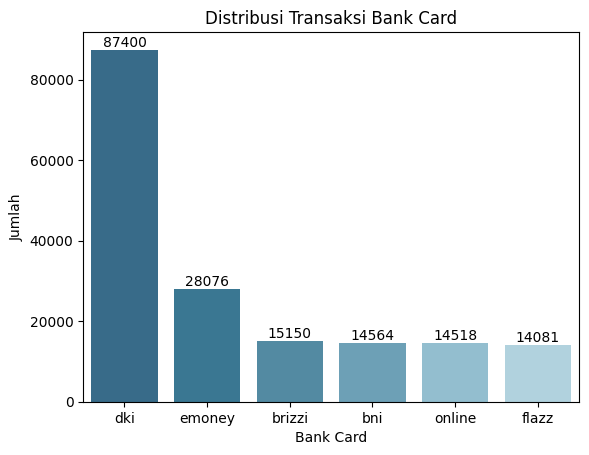

In [85]:
custom_palette = sns.color_palette(['#2a6f97', '#2c7da0', '#468faf','#61a5c2', '#89c2d9', '#a9d6e5'])
ax = sns.barplot(x='payCardBank', y='count', data=uniq_payCardBank, palette=custom_palette,)
ax.set(title='Distribusi Transaksi Bank Card', xlabel='Bank Card', ylabel='Jumlah')

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

### Distribusi Gender

In [53]:
data_sex = data['payCardSex'].replace({1: 'M', 0: 'F'})
uniq_payCardSex = data_sex.value_counts().reset_index(name='count')
uniq_payCardSex

,payCardSex,count
0,F,93535
1,M,80254


<Figure size 1200x600 with 0 Axes>

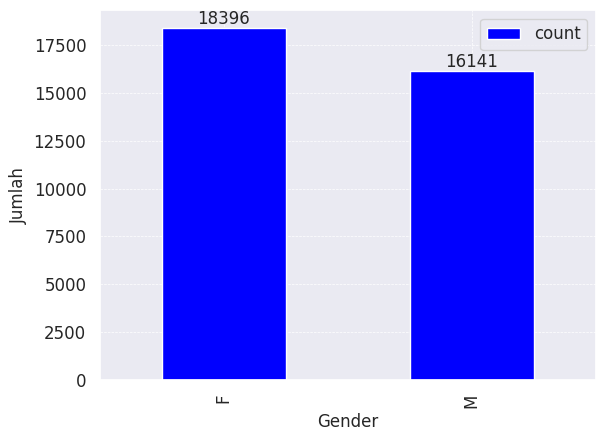

In [93]:
# Create a bar chart with adjusted figure size
plt.figure(figsize=(12, 6))
ax = uniq_payCardSex.plot(x='payCardSex', kind='bar', color='blue', fontsize=12)

# Add labels and title
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.legend(fontsize=12)

# Add text annotations above each bar
for i, v in enumerate(uniq_payCardSex['count']):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=12)

# Add grid lines
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Show the chart
plt.show()

### Grafik Direction

In [94]:
uniq_direction = data.direction.value_counts().reset_index(name='count')
uniq_direction

,direction,count
0,1.0,17288
1,0.0,17249


<Figure size 1200x600 with 0 Axes>

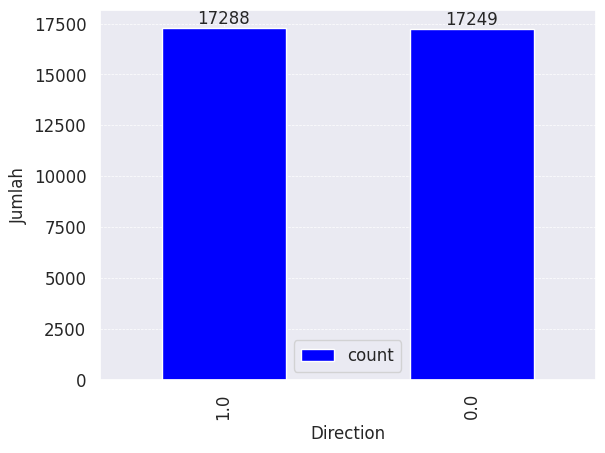

In [95]:
# Create a bar chart with adjusted figure size
plt.figure(figsize=(12, 6))
ax = uniq_direction.plot(x='direction', kind='bar', color='blue', fontsize=12)

# Add labels and title
plt.xlabel('Direction', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.legend(fontsize=12)

# Add text annotations above each bar
for i, v in enumerate(uniq_direction['count']):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=12)

# Add grid lines
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Show the chart
plt.show()

### Waktu Tersibuk

In [54]:
data['tapInTime'] = pd.to_datetime(data['tapInTime'])
data['tapOutTime'] = pd.to_datetime(data['tapOutTime'])
data['tapInHour'] = data['tapInTime'].dt.hour
data['tapOutHour'] = data['tapOutTime'].dt.hour
data['tapDay'] = data['tapInTime'].dt.dayofweek
data.head()

,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStopsName,stopStartSeq,tapInTime,tapOutStopsName,stopEndSeq,tapOutTime,payAmount,wilayah,tapInHour,tapOutHour,tapDay
37790,bni,Ir. Akarsana Januar,0,2010,1,Blok M - Kota,1.0,Kali Besar Barat,0,2023-04-19 17:09:41,Museum Fatahillah,1.0,2023-04-19 18:06:26,3500.0,1.0,17,18,2
13579,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,Tosari,9,2023-04-07 17:59:33,Mangga Besar Arah Utara,16.0,2023-04-07 19:21:51,3500.0,1.0,17,19,4
31579,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,Tosari,9,2023-04-17 17:05:20,Mangga Besar Arah Utara,16.0,2023-04-17 17:58:09,3500.0,1.0,17,17,0
56021,online,"Puji Zulaika, S.H.",0,2000,1,Blok M - Kota,1.0,Bundaran HI,11,2023-04-27 16:10:52,Kejaksaan Agung,20.0,2023-04-27 17:39:47,3500.0,1.0,16,17,3
23021,online,"Puji Zulaika, S.H.",0,2000,1,Blok M - Kota,1.0,Bundaran HI,11,2023-04-12 17:42:29,Kejaksaan Agung,20.0,2023-04-12 19:41:57,3500.0,1.0,17,19,2


In [55]:
data['tapDay'] = data['tapDay'].replace({0 : 'Senin',
                                         1 : 'Selasa', 2 : 'Rabu', 3 : 'Kamis', 4 : 'Jumat',
                                         5 : 'Sabtu', 6 : 'Minggu'})
data.head()

,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStopsName,stopStartSeq,tapInTime,tapOutStopsName,stopEndSeq,tapOutTime,payAmount,wilayah,tapInHour,tapOutHour,tapDay
37790,bni,Ir. Akarsana Januar,0,2010,1,Blok M - Kota,1.0,Kali Besar Barat,0,2023-04-19 17:09:41,Museum Fatahillah,1.0,2023-04-19 18:06:26,3500.0,1.0,17,18,Rabu
13579,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,Tosari,9,2023-04-07 17:59:33,Mangga Besar Arah Utara,16.0,2023-04-07 19:21:51,3500.0,1.0,17,19,Jumat
31579,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,Tosari,9,2023-04-17 17:05:20,Mangga Besar Arah Utara,16.0,2023-04-17 17:58:09,3500.0,1.0,17,17,Senin
56021,online,"Puji Zulaika, S.H.",0,2000,1,Blok M - Kota,1.0,Bundaran HI,11,2023-04-27 16:10:52,Kejaksaan Agung,20.0,2023-04-27 17:39:47,3500.0,1.0,16,17,Kamis
23021,online,"Puji Zulaika, S.H.",0,2000,1,Blok M - Kota,1.0,Bundaran HI,11,2023-04-12 17:42:29,Kejaksaan Agung,20.0,2023-04-12 19:41:57,3500.0,1.0,17,19,Rabu


In [38]:
unique_tapDay = data.tapDay.value_counts()
unique_tapDay

tapDay
Kamis     31446
Jumat     31425
Senin     31372
Selasa    31335
Rabu      31308
Sabtu      8496
Minggu     8407
Name: count, dtype: int64

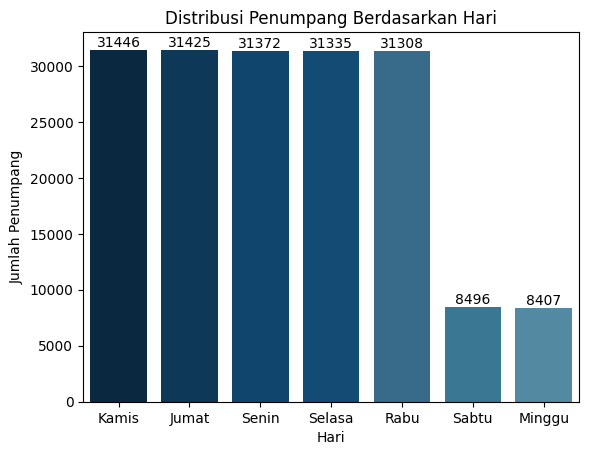

In [40]:
# Dataframe dan barplot yang telah buat sebelumnya
custom_palette = sns.color_palette(['#012a4a', '#013a63', '#01497c','#014f86', '#2a6f97', '#2c7da0', '#468faf'])
ax = sns.barplot(data=unique_tapDay, palette=custom_palette)
ax.set(title='Distribusi Penumpang Berdasarkan Hari', xlabel='Hari', ylabel='Jumlah Penumpang')

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()


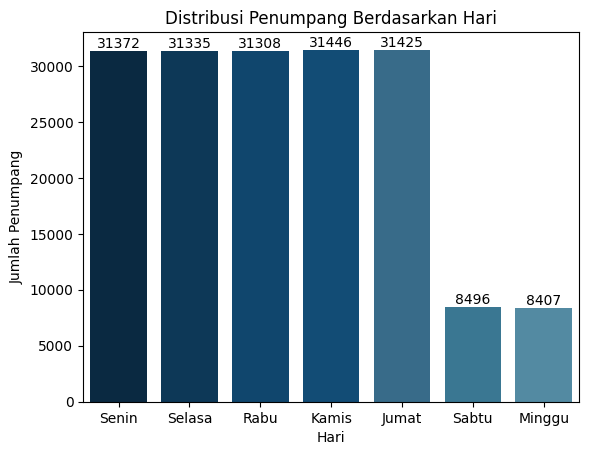

In [41]:
# Mengatur urutan kategori pada sumbu x
days_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
unique_tapDay = unique_tapDay.reindex(days_order)
# Dataframe dan barplot yang telah dibuat sebelumnya
custom_palette = sns.color_palette(['#012a4a', '#013a63', '#01497c', '#014f86', '#2a6f97', '#2c7da0', '#468faf'])
ax = sns.barplot(data=unique_tapDay, palette=custom_palette)

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

ax.set(title='Distribusi Penumpang Berdasarkan Hari', xlabel='Hari', ylabel='Jumlah Penumpang')
plt.show()

Kostumer menggunakan Transjakarta di hari-hari kerja (Senin-Jumat) dan hari dengan pengguna/penumpang terbanyak adalah hari Jumat

In [37]:
unique_tapInHour = data.tapInHour.value_counts().reset_index(name='count')
unique_tapInHour

,tapInHour,count
0,6,26770
1,17,24847
2,16,15810
3,5,15442
4,8,13152
5,7,13013
6,9,12837
7,19,11052
8,18,10967
9,20,10938


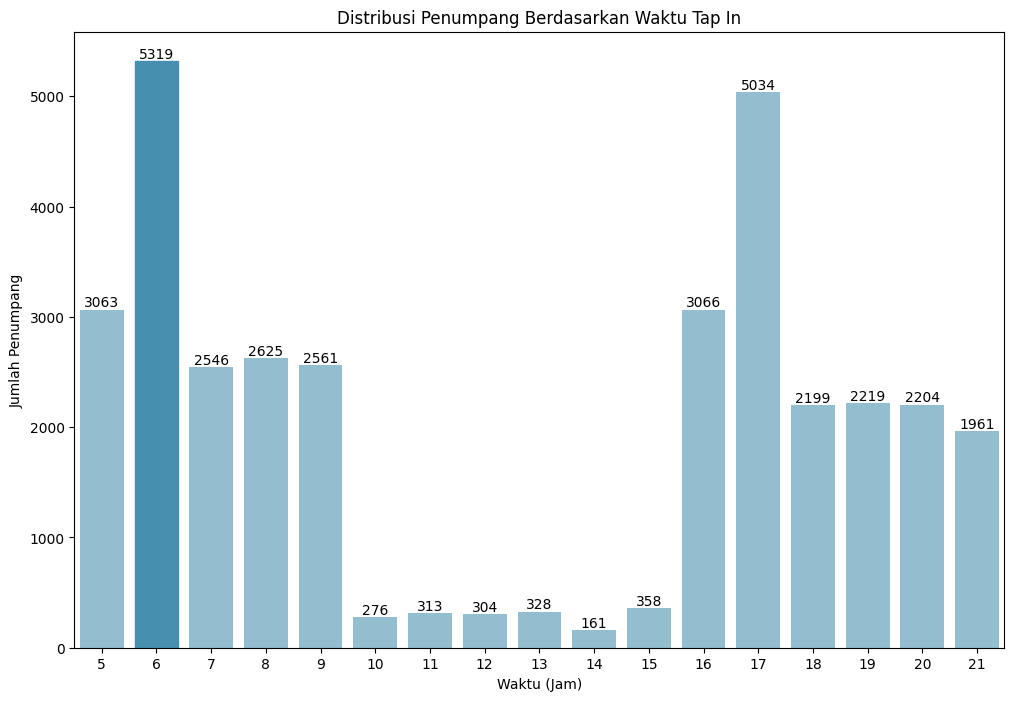

In [47]:
# Dataframe dan barplot yang telah buat sebelumnya
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='tapInHour', y='count', data=unique_tapInHour, color='#89c2d9')
ax.set(title='Distribusi Penumpang Berdasarkan Waktu Tap In', xlabel='Waktu (Jam)', ylabel='Jumlah Penumpang')

# Menentukan warna untuk bar dengan jumlah paling banyak
max_count = unique_tapInHour['count'].max()
for p in ax.patches:
    if p.get_height() == max_count:
        p.set_color('#468faf')  # Ganti warna sesuai keinginan

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

Waktu tap in terbanyak terjadi pada pukul 6 pagi dan tap in terendah pada pukul 2 siang.

In [22]:
unique_tapOutHour = data.tapOutHour.value_counts().reset_index(name='count')
unique_tapOutHour

,tapOutHour,count
0,18,20904
1,7,18668
2,19,16921
3,6,16404
4,8,13102
5,9,13077
6,10,11489
7,21,11048
8,20,11026
9,22,10083


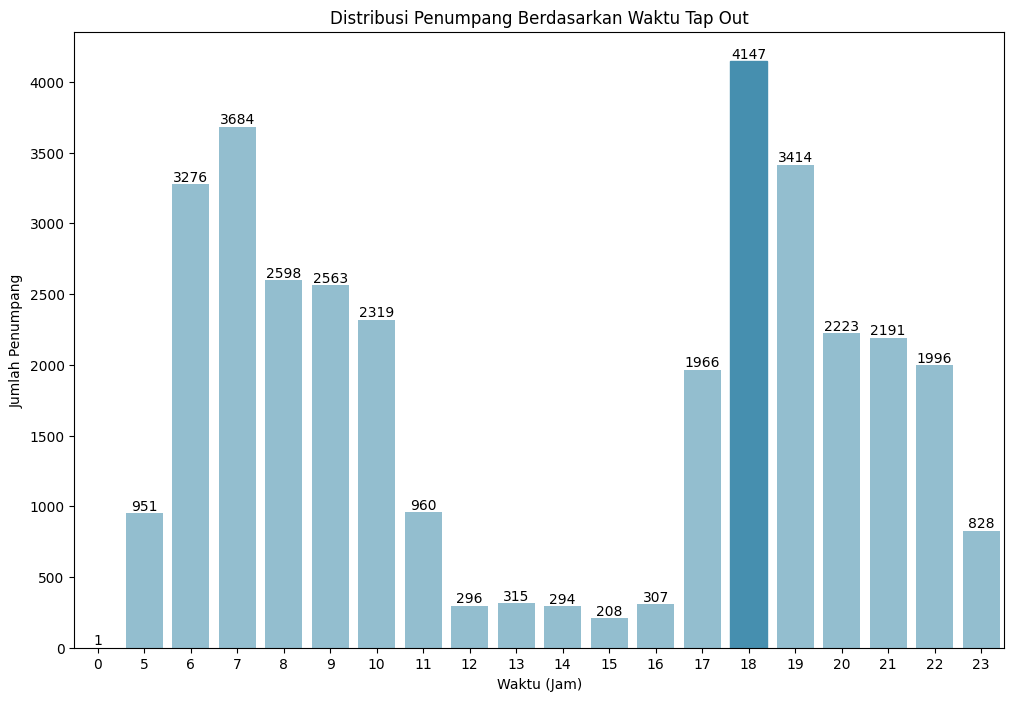

In [50]:
# Dataframe dan barplot yang telah buat sebelumnya
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='tapOutHour', y='count', data=unique_tapOutHour, color='#89c2d9')
ax.set(title='Distribusi Penumpang Berdasarkan Waktu Tap Out', xlabel='Waktu (Jam)', ylabel='Jumlah Penumpang')

# Menentukan warna untuk bar dengan jumlah paling banyak
max_count = unique_tapOutHour['count'].max()
for p in ax.patches:
    if p.get_height() == max_count:
        p.set_color('#468faf')  # Ganti warna sesuai keinginan

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

Durasi

In [56]:
data['travelDuration'] = data['tapOutTime'] - data['tapInTime']
data['travelDuration'] = data['travelDuration'].dt.total_seconds()/60
data.head()

,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStopsName,stopStartSeq,tapInTime,tapOutStopsName,stopEndSeq,tapOutTime,payAmount,wilayah,tapInHour,tapOutHour,tapDay,travelDuration
37790,bni,Ir. Akarsana Januar,0,2010,1,Blok M - Kota,1.0,Kali Besar Barat,0,2023-04-19 17:09:41,Museum Fatahillah,1.0,2023-04-19 18:06:26,3500.0,1.0,17,18,Rabu,56.750000
13579,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,Tosari,9,2023-04-07 17:59:33,Mangga Besar Arah Utara,16.0,2023-04-07 19:21:51,3500.0,1.0,17,19,Jumat,82.300000
31579,dki,Edi Siregar,1,1981,1,Blok M - Kota,0.0,Tosari,9,2023-04-17 17:05:20,Mangga Besar Arah Utara,16.0,2023-04-17 17:58:09,3500.0,1.0,17,17,Senin,52.816667
56021,online,"Puji Zulaika, S.H.",0,2000,1,Blok M - Kota,1.0,Bundaran HI,11,2023-04-27 16:10:52,Kejaksaan Agung,20.0,2023-04-27 17:39:47,3500.0,1.0,16,17,Kamis,88.916667
23021,online,"Puji Zulaika, S.H.",0,2000,1,Blok M - Kota,1.0,Bundaran HI,11,2023-04-12 17:42:29,Kejaksaan Agung,20.0,2023-04-12 19:41:57,3500.0,1.0,17,19,Rabu,119.466667


In [27]:
data.travelDuration.unique()

array([ 56.75      ,  82.3       ,  52.81666667, ..., 172.43333333,
       123.53333333, 153.        ])

In [28]:
avg_travel_duration_by_day = data.groupby('tapDay')['travelDuration'].mean()
avg_travel_duration_by_day

tapDay
Jumat     72.236394
Kamis     72.474896
Minggu    70.201860
Rabu      72.374632
Sabtu     70.514322
Selasa    72.446298
Senin     72.049600
Name: travelDuration, dtype: float64

In [25]:
data.to_csv('data.csv', index=False)

In [29]:
data.wilayah.count()

173789

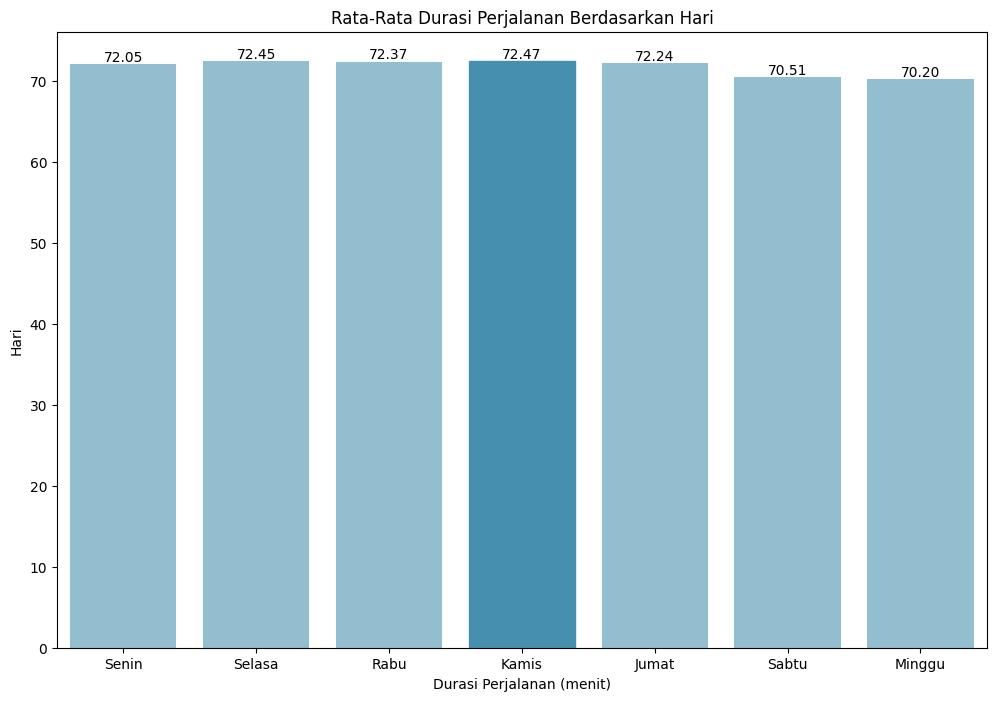

In [32]:
# Dataframe dan barplot yang telah buat sebelumnya
plt.figure(figsize=(12, 8))
# Mengatur urutan kategori pada sumbu x
days_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
avg_travel_duration_by_day = avg_travel_duration_by_day.reindex(days_order)

ax = sns.barplot(data=avg_travel_duration_by_day, color='#89c2d9')
ax.set(title='Rata-Rata Durasi Perjalanan Berdasarkan Hari', 
       xlabel='Durasi Perjalanan (menit)', ylabel='Hari')

# Menentukan warna untuk bar dengan jumlah paling banyak
max_count = avg_travel_duration_by_day.max()
for p in ax.patches:
    if p.get_height() == max_count:
        p.set_color('#468faf')  # Ganti warna sesuai keinginan

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

In [134]:
# Calculate daily average travel duration
daily_travel_duration = data.groupby('tapDay')['travelDuration'].mean()

# Find the day with the highest average travel duration
highest_avg_day = daily_travel_duration.idxmax()
highest_avg_duration = daily_travel_duration.max()

print(f"Hari dengan rata-rata durasi tertinggi: {highest_avg_day}")
print(f"Rata-rata durasi pada hari {highest_avg_day} : {highest_avg_duration:.2f} minutes")


Hari dengan rata-rata durasi tertinggi: Rabu
Rata-rata durasi pada hari Rabu : 72.57 minutes


Durasi tertinggi pada hari Rabu

### Halte Tersibuk

Tap In

In [88]:
bus_stop_counts = data['tapInStopsName'].value_counts()

# Top 10 most frequently visited bus stops
top_10_stops = bus_stop_counts.head(10)

# Print results
print("10 Halte dengan Tap In Terbanyak:")
for stop, count in top_10_stops.items():
  print(f"{stop}: {count} tapIn")

10 Halte dengan Tap In Terbanyak:
Penjaringan: 1315 tapIn
BKN: 742 tapIn
BNN LRT: 720 tapIn
Rusun Penjaringan: 619 tapIn
Garuda Taman Mini: 606 tapIn
BNN Arah Barat: 558 tapIn
Cibubur Junction: 517 tapIn
Rusun Kapuk Muara: 509 tapIn
Duren Tiga: 498 tapIn
Penggilingan: 461 tapIn


In [39]:
bus_stop_counts = data['tapInStopsName'].value_counts()

# Mengurutkan dalam urutan naik untuk mendapatkan 10 halte terkecil
top_10_stops1 = bus_stop_counts.sort_values(ascending=True).head()

# Mencetak hasil
print("10 Halte dengan Tap In Terkecil:")
for stop, count in top_10_stops1.items():
    print(f"{stop}: {count} tapIn")

10 Halte dengan Tap In Terkecil:
Pedati Prumpung 1: 1 tapIn
Masjid Darul Falah Petukangan 1: 1 tapIn
Lexington: 1 tapIn
SMK Sari Putra: 1 tapIn
Simpang Cempaka Putih Barat XXVI: 1 tapIn


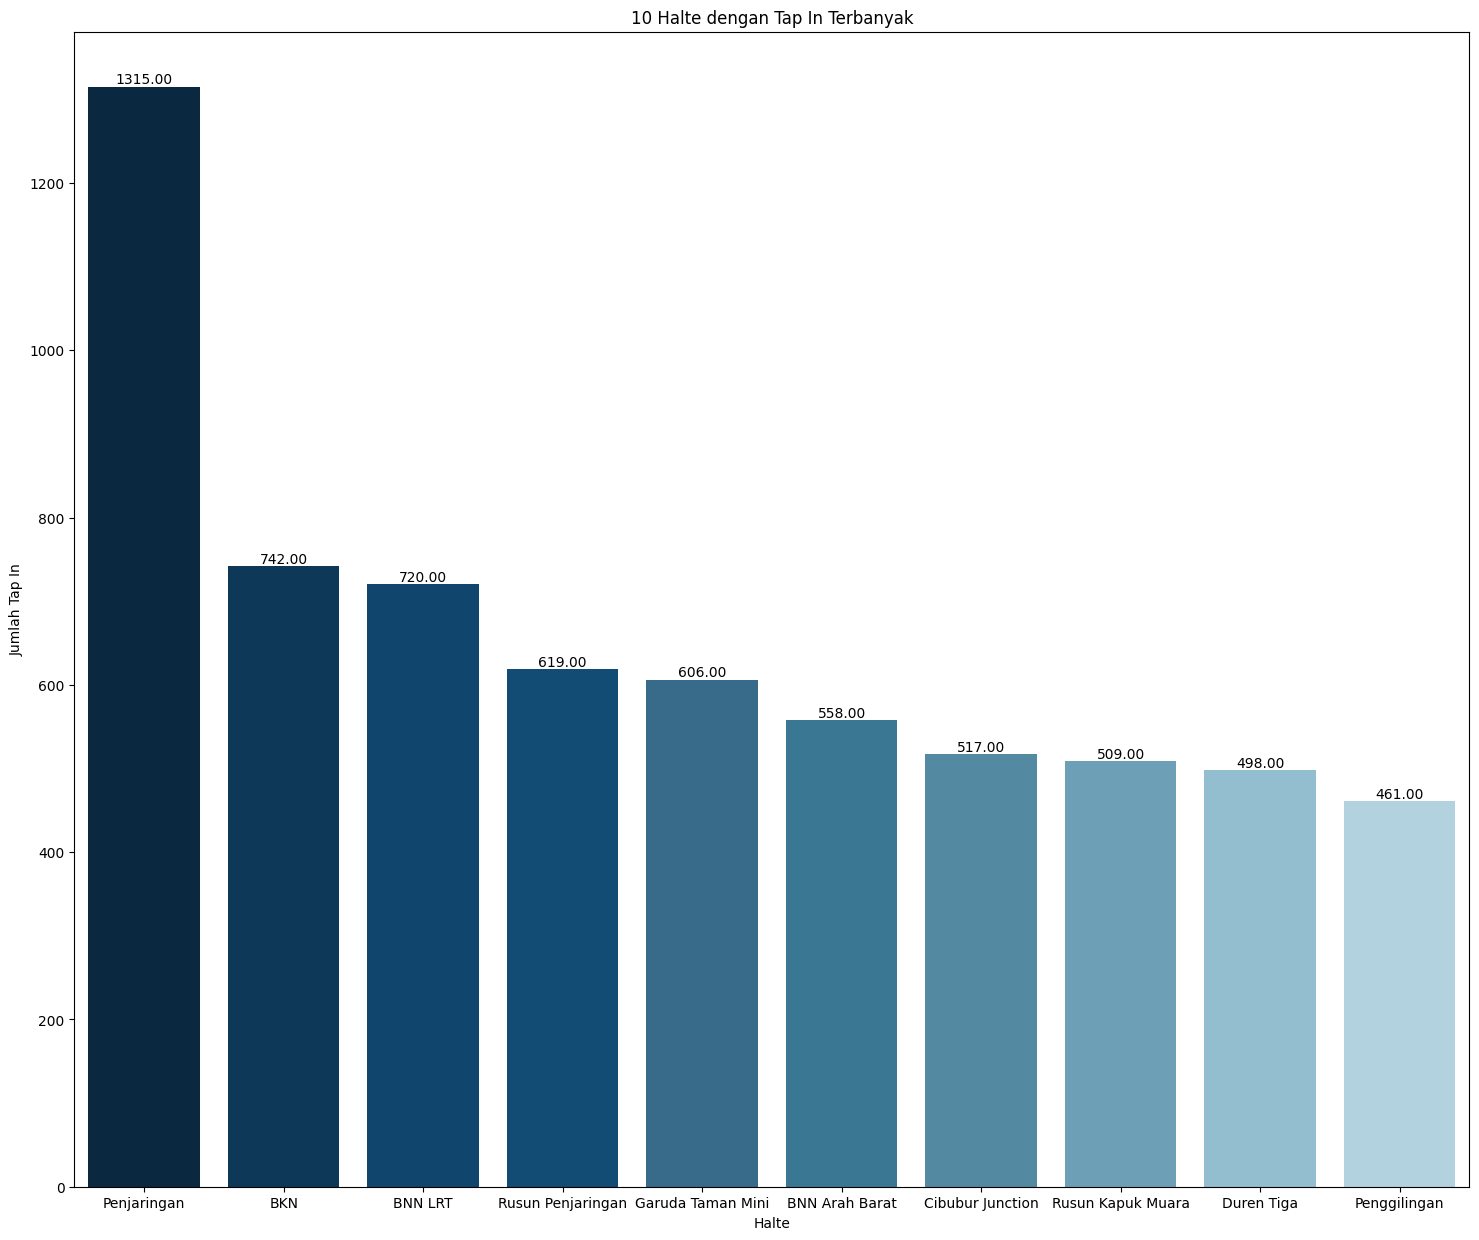

In [91]:
plt.figure(figsize=(18, 15))
ax = sns.barplot(data=top_10_stops, palette=['#012a4a','#013a63','#01497c',
                                             '#014f86','#2a6f97','#2c7da0',
                                             '#468faf','#61a5c2','#89c2d9','#a9d6e5'])
ax.set(title='10 Halte dengan Tap In Terbanyak',
       xlabel='Halte', ylabel='Jumlah Tap In')

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

Wilayah

In [49]:
bus_stop_counts31 = data['wilayah'].value_counts()

# Top 10 most frequently visited bus stops
top_10_stops31 = bus_stop_counts31.head(10)

# Print results
print("10 Halte dengan Tap In Terbanyak:")
for stop, count in top_10_stops31.items():
  print(f"{stop}: {count} tapIn")

10 Halte dengan Tap In Terbanyak:
32.0: 1232 tapIn
11.0: 1200 tapIn
13.0: 1182 tapIn
5.0: 1129 tapIn
161.0: 1120 tapIn
7.0: 1119 tapIn
219.0: 1115 tapIn
70.0: 1100 tapIn
51.0: 1100 tapIn
21.0: 1099 tapIn


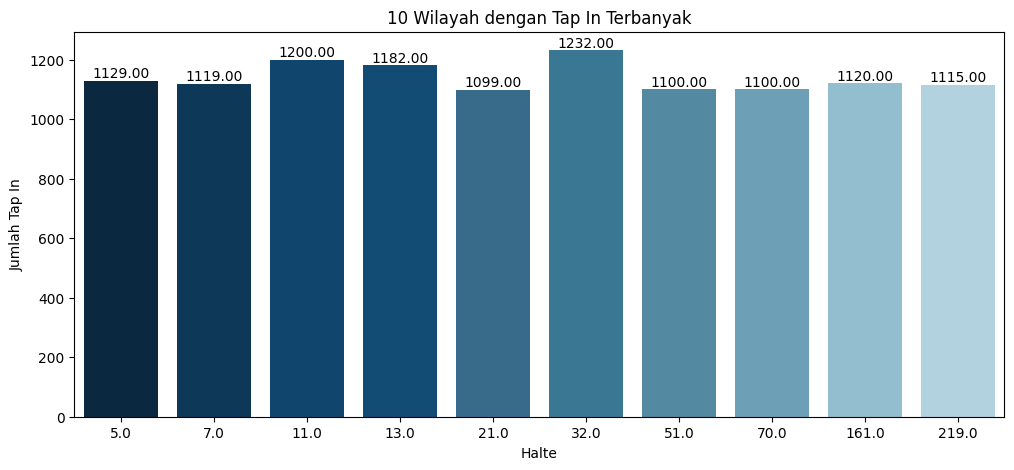

In [72]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=top_10_stops31, palette=['#012a4a','#013a63','#01497c',
                                             '#014f86','#2a6f97','#2c7da0',
                                             '#468faf','#61a5c2','#89c2d9','#a9d6e5'])
ax.set(title='10 Wilayah dengan Tap In Terbanyak',
       xlabel='Halte', ylabel='Jumlah Tap In')

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

In [44]:
bus_stop_counts3 = data['wilayah'].value_counts()

# Mengurutkan dalam urutan naik untuk mendapatkan 10 halte terkecil
top_10_stops3 = bus_stop_counts3.sort_values(ascending=True).head(10)

# Mencetak hasil
print("10 Wilayah dengan Tap In Terkecil:")
for stop, count in top_10_stops3.items():
    print(f"{stop}: {count} tapIn")

10 Wilayah dengan Tap In Terkecil:
81.0: 389 tapIn
23.0: 393 tapIn
31.0: 460 tapIn
150.0: 474 tapIn
191.0: 482 tapIn
54.0: 514 tapIn
170.0: 516 tapIn
47.0: 520 tapIn
123.0: 542 tapIn
203.0: 548 tapIn


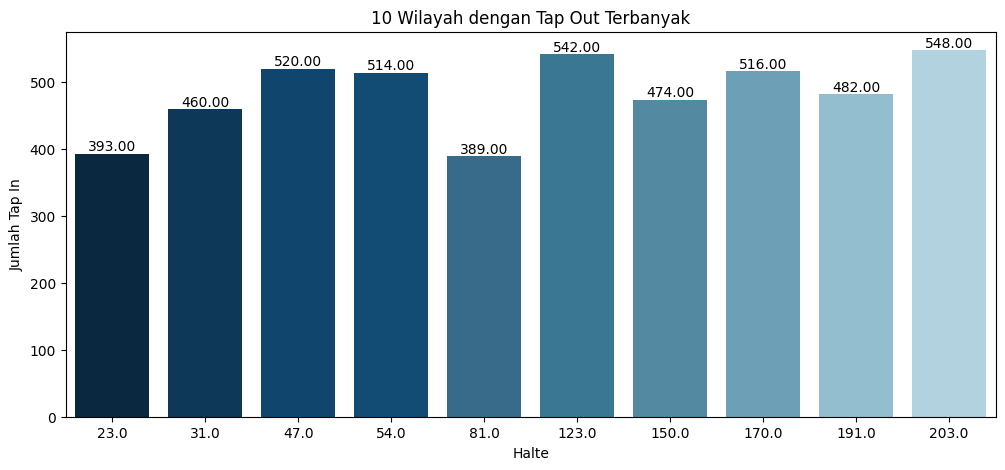

In [64]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=top_10_stops3, palette=['#012a4a','#013a63','#01497c',
                                             '#014f86','#2a6f97','#2c7da0',
                                             '#468faf','#61a5c2','#89c2d9','#a9d6e5'])
ax.set(title='10 Wilayah dengan Tap Out Terbanyak',
       xlabel='Halte', ylabel='Jumlah Tap In')

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

Tap Out

In [56]:
bus_stop_counts2 = data['tapOutStopsName'].value_counts()

# Top 10 most frequently visited bus stops
top_10_stops2 = bus_stop_counts2.head(10)

# Print results
print("10 Halte dengan Tap Out Terbanyak:")
for stop, count in top_10_stops2.items():
  print(f"{stop}: {count} tapOut")

10 Halte dengan Tap Out Terbanyak:
Penjaringan: 1537 tapOut
BKN: 1298 tapOut
Term. Senen: 689 tapOut
St. MRT Fatmawati: 652 tapOut
Cibubur Junction: 622 tapOut
Rusun Penjaringan: 613 tapOut
Puri Beta 2: 604 tapOut
BNN LRT: 602 tapOut
Bundaran Senayan: 595 tapOut
Juanda: 583 tapOut


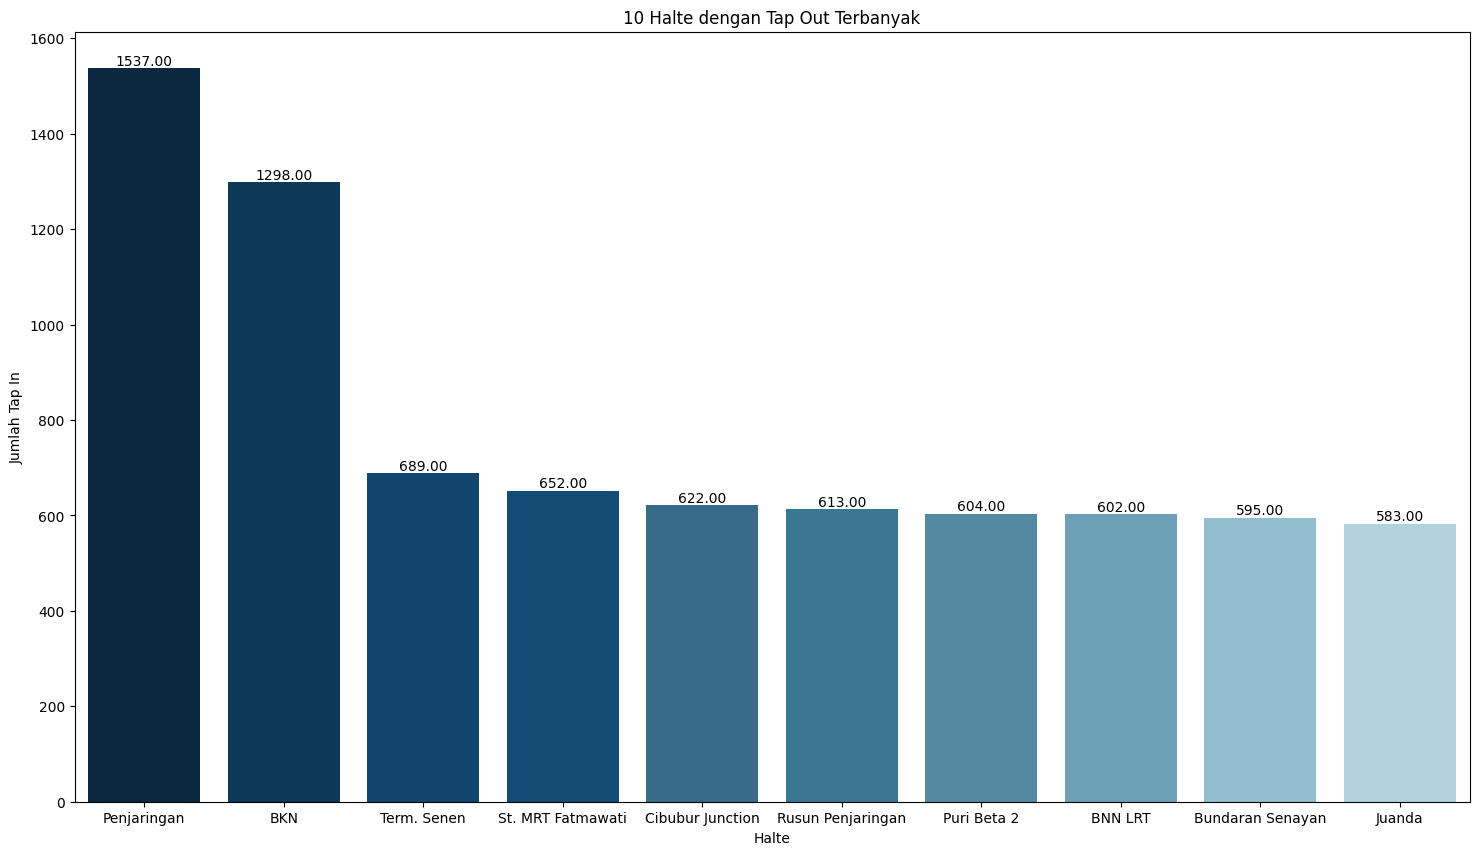

In [59]:
plt.figure(figsize=(18, 10))
ax = sns.barplot(data=top_10_stops2, palette=['#012a4a','#013a63','#01497c',
                                             '#014f86','#2a6f97','#2c7da0',
                                             '#468faf','#61a5c2','#89c2d9','#a9d6e5'])
ax.set(title='10 Halte dengan Tap Out Terbanyak',
       xlabel='Halte', ylabel='Jumlah Tap In')

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

In [51]:
bus_stop_counts4 = data['wilayah'].value_counts()

# Top 10 most frequently visited bus stops
top_10_stops4 = bus_stop_counts4.head(10)

# Print results
print("10 Halte dengan Tap Out Terbanyak:")
for stop, count in top_10_stops4.items():
  print(f"{stop}: {count} tapOut")

10 Halte dengan Tap Out Terbanyak:
32.0: 1232 tapOut
11.0: 1200 tapOut
13.0: 1182 tapOut
5.0: 1129 tapOut
161.0: 1120 tapOut
7.0: 1119 tapOut
219.0: 1115 tapOut
70.0: 1100 tapOut
51.0: 1100 tapOut
21.0: 1099 tapOut


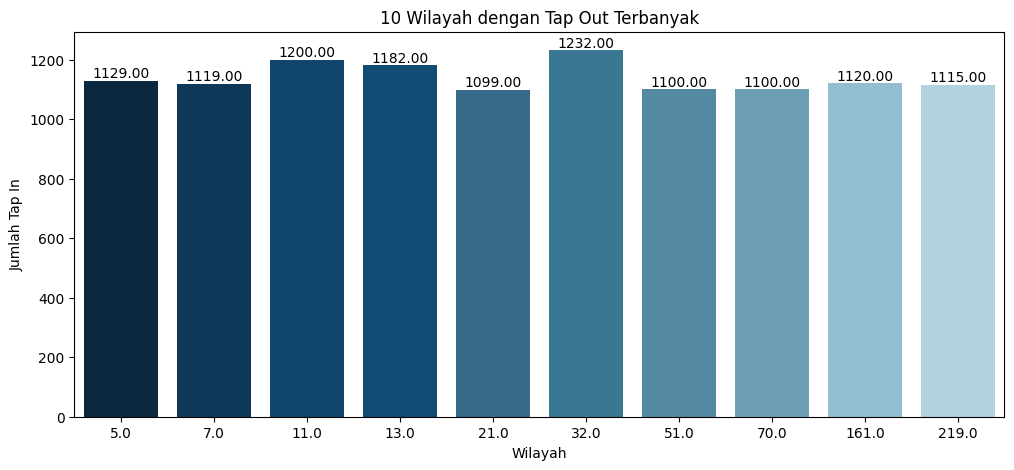

In [69]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=top_10_stops4, palette=['#012a4a','#013a63','#01497c',
                                             '#014f86','#2a6f97','#2c7da0',
                                             '#468faf','#61a5c2','#89c2d9','#a9d6e5'])
ax.set(title='10 Wilayah dengan Tap Out Terbanyak',
       xlabel='Wilayah', ylabel='Jumlah Tap In')

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

In [74]:
bus_stop_counts41 = data['wilayah'].value_counts()

# Top 10 most frequently visited bus stops
top_10_stops41 = bus_stop_counts41.sort_values(ascending=False).head(10)

# Print results
print("10 Halte dengan Tap Out Tersedikit:")
for stop, count in top_10_stops41.items():
  print(f"{stop}: {count} tapOut")

10 Halte dengan Tap Out Tersedikit:
32.0: 1232 tapOut
11.0: 1200 tapOut
13.0: 1182 tapOut
5.0: 1129 tapOut
161.0: 1120 tapOut
7.0: 1119 tapOut
219.0: 1115 tapOut
70.0: 1100 tapOut
51.0: 1100 tapOut
21.0: 1099 tapOut


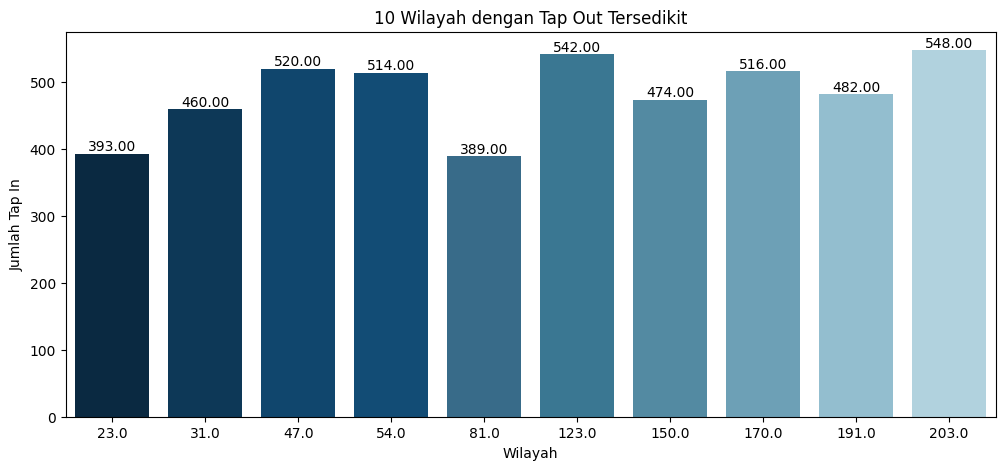

In [68]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=top_10_stops41, palette=['#012a4a','#013a63','#01497c',
                                             '#014f86','#2a6f97','#2c7da0',
                                             '#468faf','#61a5c2','#89c2d9','#a9d6e5'])
ax.set(title='10 Wilayah dengan Tap Out Tersedikit',
       xlabel='Wilayah', ylabel='Jumlah Tap In')

# Anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

# Data Modeling

## Modeling

In [1]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [57]:
customer = data[['payCardName', 'payCardBirthDate', 'payCardBank', 'payCardSex']]
# Dataset yang digunakan merupakan dataset setiap tap sepanjang waktu yang artinya akan ada duplikasi customer. Maka disini akan dilakukan penghilangan duplikasi berdasarkan nama pengguna.
customer = customer.drop_duplicates(subset='payCardName', keep='first', ignore_index=True)
customer

,payCardName,payCardBirthDate,payCardBank,payCardSex
0,Ir. Akarsana Januar,2010,bni,0
1,Edi Siregar,1981,dki,1
2,"Puji Zulaika, S.H.",2000,online,0
3,"Cut Clara Prasetyo, S.H.",1979,dki,1
4,Arsipatra Simanjuntak,2003,bni,1
...,...,...,...,...
9621,Laswi Hardiansyah,2004,dki,1
9622,Mariadi Firgantoro,1991,dki,1
9623,Dr. Tantri Palastri,1986,online,0
9624,"Raharja Kurniawan, S.Farm",1999,dki,1


### RFM Feature Engineering

Menurut Tsiptsis dan Chorianopoulos
(2009), analisis RFM terdiri Recency,
Frequency, Monetary yang memiliki pengertian
sebagai berikut :
1. Recency = merupakan variabel untuk
mengukur nilai pelanggan berdasarkan
rentang waktu (tanggal, bulan, tahun)
transaksi terakhir pelanggan sampai saat
ini. Semakin kecil rentang waktu maka nilai
recency semakin besar.
2. Frequency = merupakan variabel untuk
mengukur nilai pelanggan berdasarkan
jumlah transaksi yang dilakukan pelanggan
dalam satu periode. Semakin banyak
jumlah transaksi yang dilakukan maka nilai
f semakin besar.
3. Monetary = merupakan variabel untuk
mengukur nilai pelanggan berdasarkan
jumlah besaran uang yang dikeluarkan
pelanggan dalam satu periode. Semakin
banyak jumlah besaran uang yang
dikeluarkan pelanggan maka nilai M
semakin besar. 

In [58]:
clv = data[['payCardName']]
clv

,payCardName
37790,Ir. Akarsana Januar
13579,Edi Siregar
31579,Edi Siregar
56021,"Puji Zulaika, S.H."
23021,"Puji Zulaika, S.H."
...,...
189000,Laswi Hardiansyah
189104,Mariadi Firgantoro
189197,Dr. Tantri Palastri
189217,"Raharja Kurniawan, S.Farm"


In [59]:
# Calculate Recency (R)
data['tapOutTime'] = pd.to_datetime(data['tapOutTime']) # mengubah Dtype tapOutTime dari object menjadi datetime
max_date = data['tapOutTime'].max() # mengambil tanggal terbaru dari kolom 'tapOutTime' dalam dataframe data dan menyimpannya dalam variabel max_date
clv['Recency'] = (max_date - data['tapOutTime']).dt.days
clv

,payCardName,Recency
37790,Ir. Akarsana Januar,11
13579,Edi Siregar,23
31579,Edi Siregar,13
56021,"Puji Zulaika, S.H.",3
23021,"Puji Zulaika, S.H.",18
...,...,...
189000,Laswi Hardiansyah,7
189104,Mariadi Firgantoro,2
189197,Dr. Tantri Palastri,11
189217,"Raharja Kurniawan, S.Farm",26


In [60]:
# Calculate Frequency (F)
frequency = clv['payCardName'].value_counts().reset_index()
frequency.columns = ['payCardName', 'Frequency']
clv = clv.merge(frequency, on='payCardName')
clv

,payCardName,Recency,Frequency
0,Ir. Akarsana Januar,11,38
1,Edi Siregar,23,38
2,Edi Siregar,13,38
3,"Puji Zulaika, S.H.",3,38
4,"Puji Zulaika, S.H.",18,38
...,...,...,...
173784,Laswi Hardiansyah,7,1
173785,Mariadi Firgantoro,2,1
173786,Dr. Tantri Palastri,11,1
173787,"Raharja Kurniawan, S.Farm",26,1


In [61]:
# Calculate Monetary (M)
clv_ = data.groupby('payCardName')['payAmount'].sum().reset_index().sort_values(by='payAmount', ascending=False, ignore_index=True)
clv_

,payCardName,payAmount
0,Zulfa Siregar,842500.0
1,Rachel Puspita,840000.0
2,Rini Wasita,807000.0
3,Ulva Laksita,800000.0
4,Eluh Prabowo,800000.0
...,...,...
9621,Darmana Putra,0.0
9622,Paiman Hakim,0.0
9623,Darmana Mangunsong,0.0
9624,Paiman Saefullah,0.0


In [62]:
# mengolah table final
clv.drop_duplicates(subset='payCardName', keep='first', inplace=True)
table = pd.merge(clv,clv_)
table.rename(columns={'payAmount' : 'Monetary'}, inplace=True)
table

,payCardName,Recency,Frequency,Monetary
0,Ir. Akarsana Januar,11,38,133000.0
1,Edi Siregar,23,38,133000.0
2,"Puji Zulaika, S.H.",3,38,133000.0
3,"Cut Clara Prasetyo, S.H.",10,37,129500.0
4,Arsipatra Simanjuntak,19,37,129500.0
...,...,...,...,...
9621,Laswi Hardiansyah,7,1,0.0
9622,Mariadi Firgantoro,2,1,3500.0
9623,Dr. Tantri Palastri,11,1,3500.0
9624,"Raharja Kurniawan, S.Farm",26,1,3500.0


In [63]:
# mengolah table final
clv.drop_duplicates(subset='payCardName', keep='first', inplace=True)
table = pd.merge(clv,clv_)
table.rename(columns={'payAmount' : 'Monetary'}, inplace=True)
table

,payCardName,Recency,Frequency,Monetary
0,Ir. Akarsana Januar,11,38,133000.0
1,Edi Siregar,23,38,133000.0
2,"Puji Zulaika, S.H.",3,38,133000.0
3,"Cut Clara Prasetyo, S.H.",10,37,129500.0
4,Arsipatra Simanjuntak,19,37,129500.0
...,...,...,...,...
9621,Laswi Hardiansyah,7,1,0.0
9622,Mariadi Firgantoro,2,1,3500.0
9623,Dr. Tantri Palastri,11,1,3500.0
9624,"Raharja Kurniawan, S.Farm",26,1,3500.0


In [64]:
table

,payCardName,Recency,Frequency,Monetary
0,Ir. Akarsana Januar,11,38,133000.0
1,Edi Siregar,23,38,133000.0
2,"Puji Zulaika, S.H.",3,38,133000.0
3,"Cut Clara Prasetyo, S.H.",10,37,129500.0
4,Arsipatra Simanjuntak,19,37,129500.0
...,...,...,...,...
9621,Laswi Hardiansyah,7,1,0.0
9622,Mariadi Firgantoro,2,1,3500.0
9623,Dr. Tantri Palastri,11,1,3500.0
9624,"Raharja Kurniawan, S.Farm",26,1,3500.0


In [65]:
columns_to_scale = ['Recency', 'Frequency', 'Monetary']
scaler = MinMaxScaler()
table[columns_to_scale] = scaler.fit_transform(table[columns_to_scale])
table

,payCardName,Recency,Frequency,Monetary
0,Ir. Akarsana Januar,0.379310,0.456790,0.157864
1,Edi Siregar,0.793103,0.456790,0.157864
2,"Puji Zulaika, S.H.",0.103448,0.456790,0.157864
3,"Cut Clara Prasetyo, S.H.",0.344828,0.444444,0.153709
4,Arsipatra Simanjuntak,0.655172,0.444444,0.153709
...,...,...,...,...
9621,Laswi Hardiansyah,0.241379,0.000000,0.000000
9622,Mariadi Firgantoro,0.068966,0.000000,0.004154
9623,Dr. Tantri Palastri,0.379310,0.000000,0.004154
9624,"Raharja Kurniawan, S.Farm",0.896552,0.000000,0.004154


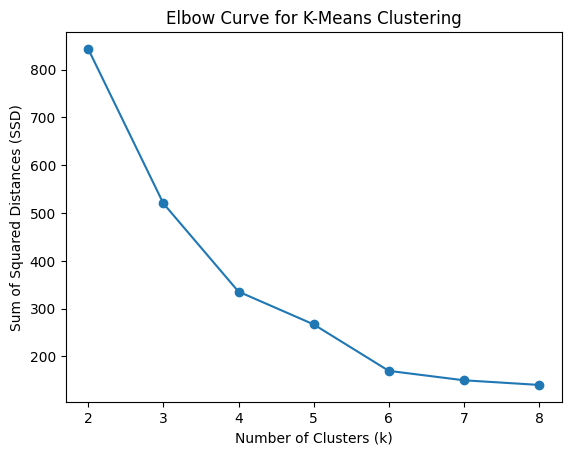

In [66]:
# Define a range of number of clusters to try (from 2 to 10 clusters)
range_n_clusters = range(2,9)

# Calculate Sum of Squared Distances (SSD) for each value of k
ssd = []
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(table[['Recency', 'Frequency', 'Monetary']])
    ssd.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range_n_clusters, ssd, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances (SSD)')
plt.title('Elbow Curve for K-Means Clustering')
plt.show()

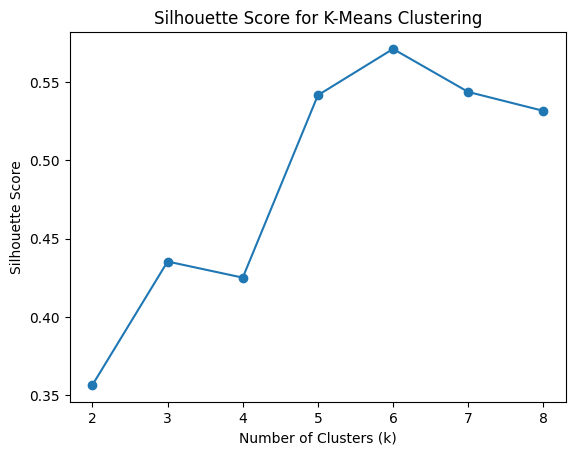

In [67]:
# Define a range of number of clusters to try (from 2 to 10 clusters)
range_n_clusters = range(2, 9)

# Calculate Silhouette Score for each value of k
silhouette_scores = []
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(table[['Recency', 'Frequency', 'Monetary']])
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(table[['Recency', 'Frequency', 'Monetary']], cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot the Silhouette Scores
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K-Means Clustering')
plt.show()

In [68]:
ssd

[843.5265878331387,
 520.1332702187514,
 335.475581418252,
 266.88620999991144,
 169.5961991094813,
 149.86959829364167,
 140.17797781823577]

In [69]:
# Perform K-Means Clustering with k=4 (4 clusters)
kmeans = KMeans(n_clusters=4)
table['Cluster'] = kmeans.fit_predict(table[['Recency', 'Frequency', 'Monetary']])
table1 = table
table1

,payCardName,Recency,Frequency,Monetary,Cluster
0,Ir. Akarsana Januar,0.379310,0.456790,0.157864,2
1,Edi Siregar,0.793103,0.456790,0.157864,2
2,"Puji Zulaika, S.H.",0.103448,0.456790,0.157864,0
3,"Cut Clara Prasetyo, S.H.",0.344828,0.444444,0.153709,2
4,Arsipatra Simanjuntak,0.655172,0.444444,0.153709,2
...,...,...,...,...,...
9621,Laswi Hardiansyah,0.241379,0.000000,0.000000,0
9622,Mariadi Firgantoro,0.068966,0.000000,0.004154,0
9623,Dr. Tantri Palastri,0.379310,0.000000,0.004154,1
9624,"Raharja Kurniawan, S.Farm",0.896552,0.000000,0.004154,1


#### Heatmap

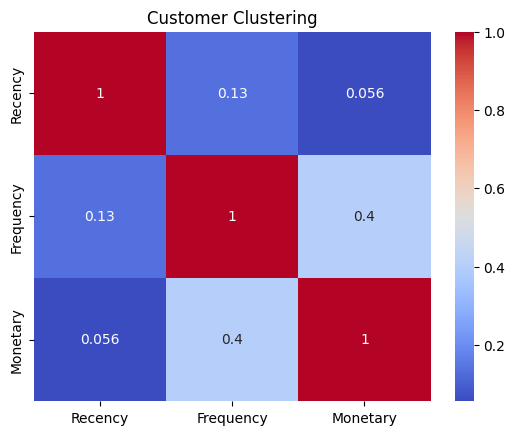

In [70]:
selected_columns = ['Recency', 'Frequency', 'Monetary']
sns.heatmap(table[selected_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Customer Clustering')
plt.show()

In [71]:
table1[['Cluster', 'Recency', 'Frequency', 'Monetary']].groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,0.153507,0.152656,0.031632
1,0.608393,0.053149,0.017450
2,0.620280,0.455911,0.084501
3,0.502292,0.453936,0.887734


In [72]:
# Perform K-Means Clustering with k=3 (3 clusters)
kmeans = KMeans(n_clusters=3)
table['Cluster'] = kmeans.fit_predict(table[['Recency', 'Frequency', 'Monetary']])
table2 = table
table2

,payCardName,Recency,Frequency,Monetary,Cluster
0,Ir. Akarsana Januar,0.379310,0.456790,0.157864,0
1,Edi Siregar,0.793103,0.456790,0.157864,0
2,"Puji Zulaika, S.H.",0.103448,0.456790,0.157864,1
3,"Cut Clara Prasetyo, S.H.",0.344828,0.444444,0.153709,0
4,Arsipatra Simanjuntak,0.655172,0.444444,0.153709,0
...,...,...,...,...,...
9621,Laswi Hardiansyah,0.241379,0.000000,0.000000,1
9622,Mariadi Firgantoro,0.068966,0.000000,0.004154,1
9623,Dr. Tantri Palastri,0.379310,0.000000,0.004154,2
9624,"Raharja Kurniawan, S.Farm",0.896552,0.000000,0.004154,2


In [73]:
table2[['Cluster', 'Recency', 'Frequency', 'Monetary']].groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,0.615112,0.455829,0.128838
1,0.153202,0.153454,0.034353
2,0.608393,0.053149,0.017450
